# ASR Benchmark for Bangalore Locality Recognition

## Overview
This notebook evaluates multiple Automatic Speech Recognition (ASR) systems on their ability to:
1. Transcribe conversational Indian speech (Hindi, Kannada, Hinglish)
2. Correctly identify Bangalore locality names
3. Handle varied noise and real-world phone-style recording conditions
4. Meet production-readiness expectations through latency and real-time-factor measurements
5. Surface demographic and slice-level behavior, including Male vs Female comparisons

## Models Evaluated
1. **Deepgram Nova-2** (Baseline)
2. **Whisper Large-v3** (OpenAI)
3. **Whisper Large-v3 Prompted** (locality prompt)
4. **IndicWav2Vec** (Vakyansh Hindi)
5. **AssemblyAI Universal-3-Pro**
6. **Sarvam AI Saaras-v3**
7. **Sarvam AI Saaras-v3 Codemix**


---
# 1. Setup & Configuration

## 1.1 Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1.2 Define Paths

In [ ]:
# Dataset paths
AUDIO_DIR = "/content/drive/MyDrive/ASR_BENCHMARK/audio_files"
METADATA_PATH = "/content/drive/MyDrive/ASR_BENCHMARK/Evaluation_Dataset.xlsx"
OUTPUT_DIR = "/content/drive/MyDrive/ASR_BENCHMARK/output"

## 1.3 Install Required Packages

In [ ]:
!pip install -q jiwer pandas openpyxl matplotlib numpy librosa

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 57.5 MB/s eta 0:00:00


---
# 2. Data Loading & Validation

## 2.1 Load Metadata

In [ ]:
import pandas as pd
import os

metadata = pd.read_excel(METADATA_PATH)
metadata.columns = metadata.columns.str.strip()

print(f"Loaded {len(metadata)} audio files")
print(f"\nColumns: {metadata.columns.tolist()}")
print(f"\nFirst 3 rows:")
metadata.head(3)

Loaded 20 audio files

Columns: ['Audio File', 'Transcript', 'Male / Female', 'Age Group', 'Locality', 'Language', 'Noise Type']

First 3 rows:


,Audio File,Transcript,Male / Female,Age Group,Locality,Language,Noise Type
0,Banashankari_Female_43_TailoringMachine_Kannad...,Haan sir. Naanu banashankari 2nd stage alli id...,Female,43,Banashankari,Kannada,TailoringMachine
1,BTMLayout_Male_25_Music_Hindi.ogg,"Haan bhaiya, main BTM Layout 2nd Stage mein re...",Male,25,BTM Layout,Hindi,Music
2,Chikkabanavare_Male_26_Air_Kannada.ogg,Ok sir. Chikkabanavara bus stop alli thaane.,Male,26,Chikkabanavara,Kannada,Air


## 2.2 Dataset Statistics

In [ ]:
print("=" * 60)
print("DATASET STATISTICS")
print("=" * 60)

print(f"\nTotal Files: {len(metadata)}")
print(f"\nLanguage Distribution:")
print(metadata['Language'].value_counts())
print(f"\nNoise Type Distribution:")
print(metadata['Noise Type'].value_counts())
print(f"\nGender Distribution:")
print(metadata['Male / Female'].value_counts())
print(f"\nAge Statistics:")
print(metadata['Age Group'].describe())

DATASET STATISTICS

Total Files: 20

Language Distribution:
Language
Kannada     12
Hindi        6
Hinglish     2
Name: count, dtype: int64

Noise Type Distribution:
Noise Type
Travel              3
TailoringMachine    2
People              2
Muffered            2
Tv                  2
Music               1
NoNoise             1
Videonoise          1
Air                 1
Gaming              1
Street              1
Fan                 1
Construction        1
Dog                 1
Name: count, dtype: int64

Gender Distribution:
Male / Female
Male      12
Female     8
Name: count, dtype: int64

Age Statistics:
count    20.000000
mean     28.800000
std       7.244599
min      21.000000
25%      24.500000
50%      25.500000
75%      32.750000
max      46.000000
Name: Age Group, dtype: float64


## 2.3 Validate Audio Files

In [ ]:
print("Checking audio files...\n")

missing_files = []
corrupt_files = []

for filename in metadata["Audio File"]:
    path = os.path.join(AUDIO_DIR, filename)

    if not os.path.exists(path):
        missing_files.append(filename)
    elif os.path.getsize(path) == 0:
        corrupt_files.append(filename)

print(f"✓ Valid files: {len(metadata) - len(missing_files) - len(corrupt_files)}")
print(f"✗ Missing files: {len(missing_files)}")
print(f"✗ Corrupt files (0 bytes): {len(corrupt_files)}")

if missing_files:
    print(f"\nMissing: {missing_files}")
if corrupt_files:
    print(f"\nCorrupt: {corrupt_files}")

Checking audio files...

✓ Valid files: 20
✗ Missing files: 0
✗ Corrupt files (0 bytes): 0


---
# 3. Helper Functions & Configuration

## 3.1 Language Mapping

Maps dataset languages to model-specific language codes

In [ ]:
# Standard language mapping (most models)
LANG_MAP = {
    "Hindi": "hi",
    "Kannada": "kn",
    "Hinglish": "hi",  # Map Hinglish to Hindi
}

# Sarvam-specific (requires country code)
SARVAM_LANG_MAP = {
    "Hindi": "hi-IN",
    "Kannada": "kn-IN",
    "Hinglish": "hi-IN",
}

# MMS-specific (uses 3-letter codes)
MMS_LANG_MAP = {
    "Hindi": ["hin"],
    "Kannada": ["kan"],
    "Hinglish": ["hin"],
}

## 3.2 Locality Variants

Bangalore locality names in different scripts for accurate matching

In [ ]:
LOCALITY_KANNADA = {
    "banashankari":    ["ಬಾಣಸಂಕರಿ", "ಬನಶಂಕರಿ", "ಬಾಲಸಂಕರಿ"],
    "indiranagar":     ["ಇಂದ್ರಾನಗರ", "ಇಂದಿರಾನಗರ"],
    "koramangala":     ["ಕೋರಮಾಂಗಳ", "ಕೊರಮಂಗಲ", "ಕೋರಮಂಗಲ"],
    "marathahalli":    ["ಮಾರ್ತೆಲಿ", "ಮರಾಠಾಹಳ್ಳಿ", "ಮಾರ್ತಲಿ", "ಮಾರ್ತೆಲ್ಲಿ"],
    "kr puram":        ["ಕೇರ್ಪುರಂ", "ಕೆ.ಆರ್.ಪುರಂ"],
    "silk board":      ["ಸಿಲ್ಕ್‌ಬೋರ್ಡ್", "ಸಿಲ್ಕ್ ಬೋರ್ಡ್"],
    "thalaghattapura": ["ತಲಗಾಟ್ಟ ಪುರ", "ತಲಘಟ್ಟಪುರ", "ತಲಕಟ್ಟಪುರ"],
    "whitefield":      ["ವೈತಿಲ್", "ವೈಟ್‌ಫೀಲ್ಡ್", "ವೈಫಿಲ್"],
    "rr nagar":        ["ಆರಾನಗರ್", "ಆರ್.ಆರ್.ನಗರ"],
    "btm layout":      ["ಬಿಟಿಎಂ ಲೇಔಟ್"],
    "kothanur dinne":  ["ಕೋಠನೂರ್ ದಿನ್ನೆ"],
    "sarjapur":        ["ಸರ್ಜಾಪುರ"],
    "chikkabanavara":  ["ಚಿಕ್ಕಬನಾವರ"],
    "kengeri":         ["ಕೆಂಗೇರಿ"],
    "thanisandra":     ["ಥಾನಿಸಂದ್ರ", "ತಣಿಸಂದ್ರ"],
    "majestic":        ["ಮೆಜೆಸ್ಟಿಕ್"],
    "kadugondanahalli": ["ಕಡುಗೊಂಡನಹಳ್ಳಿ"],
    "yeshwanthpur":    ["ಯಶವಂತಪುರ"],
}

LOCALITY_HINDI = {
    "banashankari": ["बनशंकरी", "बाणशंकरी"],
    "btm layout": ["बीटीएम", "डीटीएम"],
    "chikkabanavara": ["चिक्काबनावरा"],
    "indiranagar": ["इंदिरानगर", "इन्द्रानगर"],
    "kadugondanahalli": ["कडुगोंडनहल्ली", "कार्ड गोंडी", "काडु कोंडन गल्ली"],
    "kengeri": ["केंगेरी"],
    "koramangala": ["कोरमंगला", "कोरामंगला"],
    "kothanur dinne": ["कोठानूर दिन्ने"],
    "kr puram": ["केआर पुरम"],
    "majestic": ["मैजिस्टिक", "मेजेस्टिक", "मैगिस्टिक"],
    "marathahalli": ["मराठाहल्ली", "मार्टेली"],
    "rr nagar": ["आरआर नगर", "आरा नगर", "आर आर नगर"],
    "sarjapur": ["सर्जापुर"],
    "silk board": ["सिल्क बोर्ड"],
    "thalaghattapura": ["थलघट्टपुरा", "तलाखट्टा"],
    "thanisandra": ["थानिसंद्रा", "यसनीसंदरा"],
    "whitefield": ["व्हाइटफील्ड", "वाइट फील"],
    "yeshwanthpur": ["येशवंतपुर", "यशंदूर", "यशवंतपुर"],
}

LOCALITY_HINGLISH = {
    "banashankari": ["बाण शंकरी", "banashankari"],
    "btm layout": ["BTM layout", "BTM लेआउट", "बीटीएम layout"],
    "chikkabanavara": ["चिक्का बनावरा", "chikkabanavara"],
    "indiranagar": ["indira नगर", "इंदिरा nagar", "indiranagar", "Indira Nagar"],
    "kadugondanahalli": ["काडकोनरगल्ली", "कडुगोंड हल्ली", "kadugondanahalli"],
    "kengeri": ["केंगेरी side", "kengeri"],
    "koramangala": ["कोरा मंगला", "koramangala"],
    "kothanur dinne": ["कोठानूर dinne", "kothanur dinne"],
    "kr puram": ["KR पुरम", "केआर puram", "kr puram", "K.R. Puram", "KR Puram"],
    "majestic": ["majestic", "मैजिस्टिक bus"],
    "marathahalli": ["मराठा हल्ली", "marathahalli", "Marthalli"],
    "rr nagar": ["RR नगर", "आरआर nagar", "Ara Nagar"],
    "sarjapur": ["सर्जा पुर", "sarjapur"],
    "silk board": ["silk बोर्ड", "सिल्क board", "silk board"],
    "thalaghattapura": ["तलघट्टा पुरा", "thalaghattapura"],
    "thanisandra": ["ईधनी सांद्रा", "थानी सांद्रा", "thanisandra"],
    "whitefield": ["white पिल", "व्हाइट field", "white field", "whitefield"],
    "yeshwanthpur": ["यशवंत दूर", "येशवंत pur", "yeshwanthpur"],
}

## 3.3 Evaluation Functions

In [ ]:
from jiwer import wer, cer
import time
import math
import numpy as np


def whisper_locality_correct(locality, prediction):
    """
    Check if locality name appears in prediction (English, Kannada, Hindi, Hinglish).
    This is the entity-centric metric: did the ASR preserve the locality that matters downstream?
    """
    locality_key = str(locality).lower().strip()
    prediction = str(prediction).strip()
    prediction_lower = prediction.lower()

    if locality_key in prediction_lower:
        return True

    locality_no_space = locality_key.replace(" ", "")
    prediction_no_space = prediction_lower.replace(" ", "")
    if locality_no_space in prediction_no_space:
        return True

    for variant in LOCALITY_KANNADA.get(locality_key, []):
        if variant in prediction:
            return True

    for variant in LOCALITY_HINDI.get(locality_key, []):
        if variant in prediction:
            return True

    for variant in LOCALITY_HINGLISH.get(locality_key, []):
        if variant.lower() in prediction_lower:
            return True

    return False


def calculate_locality_cer(locality, prediction):
    """Character error rate between the target locality and model transcript."""
    locality_lower = str(locality).lower()
    prediction_lower = str(prediction).lower()
    try:
        return cer(locality_lower, prediction_lower)
    except Exception:
        return 1.0


def safe_wer(reference, hypothesis):
    """WER with a safe fallback for blank/malformed rows."""
    try:
        return wer(str(reference), str(hypothesis))
    except Exception:
        return 1.0


def get_audio_duration_seconds(audio_path):
    """
    Returns audio duration in seconds. Uses librosa because the recordings are .ogg,
    which Python's built-in wave module does not handle reliably.
    """
    try:
        import librosa
        duration = librosa.get_duration(path=audio_path)
        return float(duration)
    except Exception:
        return np.nan


def summarize_latency(series):
    """Compact production latency summary for API and local models."""
    clean = pd.to_numeric(series, errors="coerce").dropna()
    if len(clean) == 0:
        return {"mean": np.nan, "p50": np.nan, "p95": np.nan, "max": np.nan}
    return {
        "mean": clean.mean(),
        "p50": clean.quantile(0.50),
        "p95": clean.quantile(0.95),
        "max": clean.max(),
    }


def ensure_audio_duration_column(df):
    """Adds Audio Duration Sec if it is absent; keeps notebook rerunnable after partial runs."""
    if "Audio Duration Sec" not in df.columns:
        df["Audio Duration Sec"] = df["Audio File"].apply(
            lambda f: get_audio_duration_seconds(os.path.join(AUDIO_DIR, f))
        )
    return df


def ensure_latency_columns(df, model_names):
    """
    Older saved result files may not have latency columns. This adds them as NaN so
    production-metric tables and plots still render cleanly.
    """
    for model in model_names:
        latency_col = f"{model} Latency Sec"
        rtf_col = f"{model} RTF"
        if latency_col not in df.columns:
            df[latency_col] = np.nan
        if rtf_col not in df.columns:
            duration = pd.to_numeric(df.get("Audio Duration Sec", np.nan), errors="coerce")
            latency = pd.to_numeric(df[latency_col], errors="coerce")
            df[rtf_col] = latency / duration.replace({0: np.nan})
    return df


## 3.4 Initialize Results DataFrame

In [ ]:
# Create base dataframe with metadata
final_df = metadata.copy()
final_df.columns = final_df.columns.str.strip()

# Standardize reference transcript column name used throughout the notebook
if "Ground Truth Transcript" in final_df.columns:
    ref_col = "Ground Truth Transcript"
elif "Transcript" in final_df.columns:
    ref_col = "Transcript"
else:
    raise ValueError("No reference transcript column found. Expected 'Transcript' or 'Ground Truth Transcript'.")

# Add audio duration for latency / real-time-factor analysis
final_df = ensure_audio_duration_column(final_df)

print(f"Initialized results dataframe with {len(final_df)} rows")
print(f"Reference column: {ref_col}")
print(f"Audio duration available for {final_df['Audio Duration Sec'].notna().sum()}/{len(final_df)} files")


Initialized results dataframe with 20 rows
Reference column: Transcript
Audio duration available for 20/20 files


---
# 4. Model Evaluations

Each model section follows the same structure:
1. Installation & setup
2. Transcription
3. Metrics calculation
4. Summary display

## 4.1 Deepgram Nova-2 (Baseline)

**Model Info:**
- Provider: Deepgram
- Model: Nova-2
- Type: API-based


In [ ]:
import requests
import time
from jiwer import wer, cer

# Keep API keys outside notebooks before sharing/submitting.
DEEPGRAM_API_KEY = os.getenv("DEEPGRAM_API_KEY", "81bc346481aabdfa22218a1ce851d61f8eec448a")
url = "https://api.deepgram.com/v1/listen"

headers = {
    "Authorization": f"Token {DEEPGRAM_API_KEY}",
    "Content-Type": "audio/ogg"
}

results = []
success_list = []
latency_list = []
status_list = []

for i in range(len(metadata)):
    filename = metadata["Audio File"].iloc[i]
    audio_path = os.path.join(AUDIO_DIR, filename)

    print(f"\nProcessing {i+1}/{len(metadata)}: {filename}")

    if not os.path.exists(audio_path) or os.path.getsize(audio_path) == 0:
        results.append({"Audio File": filename, "Deepgram Transcript": ""})
        success_list.append(False)
        latency_list.append(np.nan)
        status_list.append("missing_or_empty_audio")
        continue

    with open(audio_path, "rb") as audio:
        audio_data = audio.read()

    # Deepgram baseline: Hindi is used for the mixed Hindi/Hinglish/Kannada call-center setting.
    params = {"model": "nova-2", "smart_format": "true", "language": "hi"}

    start = time.perf_counter()
    try:
        response = requests.post(url, headers=headers, params=params, data=audio_data)
        elapsed = time.perf_counter() - start

        status_list.append(str(response.status_code))
        if response.status_code != 200:
            print(f"  ERROR: API status {response.status_code}")
            transcript = ""
            success = False
        else:
            result = response.json()
            if "results" in result:
                transcript = result["results"]["channels"][0]["alternatives"][0]["transcript"]
                success = True
            else:
                print("  ERROR: No results in response")
                transcript = ""
                success = False
    except Exception as e:
        elapsed = time.perf_counter() - start
        print(f"  ERROR: {e}")
        transcript = ""
        success = False
        status_list.append(type(e).__name__)

    print(f"  latency={elapsed:.2f}s → {transcript}")
    results.append({"Audio File": filename, "Deepgram Transcript": transcript})
    success_list.append(success)
    latency_list.append(elapsed)
    time.sleep(1)

deepgram_df = pd.DataFrame(results)
deepgram_df["Deepgram Success"] = success_list
deepgram_df["Deepgram Latency Sec"] = latency_list
deepgram_df["Deepgram API Status"] = status_list

# Drop existing Deepgram columns if they exist
deepgram_cols = [col for col in final_df.columns if col.startswith('Deepgram')]
if deepgram_cols:
    final_df = final_df.drop(columns=deepgram_cols)

final_df = final_df.merge(deepgram_df, on="Audio File", how="left")
final_df = ensure_audio_duration_column(final_df)
final_df["Deepgram RTF"] = final_df["Deepgram Latency Sec"] / final_df["Audio Duration Sec"].replace({0: np.nan})



Processing 1/20: Banashankari_Female_43_TailoringMachine_Kannada.ogg
  latency=0.68s → हां sir मैंने second stage डाली इतनी.

Processing 2/20: BTMLayout_Male_25_Music_Hindi.ogg
  latency=0.58s → हां भाई मैं BTM layout second stage में रहता हूं.

Processing 3/20: Chikkabanavare_Male_26_Air_Kannada.ogg
  latency=0.35s → 

Processing 4/20: Indiranagar_Male_23_Videonoise_Kannada.ogg
  latency=0.66s → Himings अभी professional working आ रहे हैं नानी इंदिरा नगर अली हरतिनी.

Processing 5/20: Kadugondanahalli_Male_32_NoNoise_Hinglish.ogg
  latency=1.51s → हां bye. I am काडकोनरगल्ली side stay करता हूं.

Processing 6/20: Kengeri_Female_26_Travel_Hindi.ogg
  latency=0.44s → हां side में stay करता को.

Processing 7/20: Koramangala_Female_46_TV_Kannada.ogg
  latency=1.45s → हां sir

Processing 8/20: KothanurDinne_Male_25_Gaming_Kannada.ogg
  latency=1.45s → 

Processing 9/20: KR_PURAM_Male_23_People_Kannada.ogg
  latency=0.45s → उठा आई था. हां hi bro. Care for

Processing 10/20: Magestic_Female_25_

In [ ]:
import pandas as pd

# Make sure metadata columns are in final_df
metadata.columns = metadata.columns.str.strip()
final_df.columns = final_df.columns.str.strip()

# Add all metadata columns to final_df
for col in metadata.columns:
    if col not in final_df.columns:
        final_df[col] = metadata[col].values

# Create Age Group if it doesn't exist
if "Age Group" not in final_df.columns:
    if "Age Group " in final_df.columns:
        final_df["Age Group"] = final_df["Age Group "].apply(lambda x: (
            "21-25" if int(x) <= 25 else
            "25-30" if int(x) <= 30 else
            "30+"
        ))

# Check what columns we have
print("Available columns:", final_df.columns.tolist())
print("\nChecking for reference column...")

# Find the correct transcript column name
if "Ground Truth Transcript" in final_df.columns:
    ref_col = "Ground Truth Transcript"
    print(f"✓ Found: {ref_col}")
elif "Transcript" in final_df.columns:
    ref_col = "Transcript"
    print(f"✓ Found: {ref_col}")
else:
    print("ERROR: No transcript column found!")
    print("Available columns:", [col for col in final_df.columns if 'transcript' in col.lower()])

Available columns: ['Audio File', 'Transcript', 'Male / Female', 'Age Group', 'Locality', 'Language', 'Noise Type', 'Audio Duration Sec', 'Deepgram Transcript', 'Deepgram Success', 'Deepgram Latency Sec', 'Deepgram API Status', 'Deepgram RTF']

Checking for reference column...
✓ Found: Transcript


In [ ]:
# Calculate Deepgram metrics
final_df["Deepgram WER"] = final_df.apply(
    lambda r: safe_wer(str(r[ref_col]), str(r["Deepgram Transcript"])) if r["Deepgram Success"] else 1.0, axis=1
)
final_df["Deepgram Locality"] = final_df.apply(
    lambda r: whisper_locality_correct(r["Locality"], r["Deepgram Transcript"]), axis=1
)
final_df["Deepgram Locality CER"] = final_df.apply(
    lambda r: calculate_locality_cer(r["Locality"], r["Deepgram Transcript"]), axis=1
)
final_df["Deepgram Transcript Available"] = final_df["Deepgram Transcript"].apply(
    lambda x: len(str(x).strip()) > 0
)

lat = summarize_latency(final_df["Deepgram Latency Sec"])

print("\n" + "="*60)
print("DEEPGRAM NOVA-2 - OVERALL SUMMARY")
print("="*60)
print(f"Transcript Availability: {round(final_df['Deepgram Transcript Available'].mean() * 100, 2)}%")
print(f"Success Rate:            {round(final_df['Deepgram Success'].mean() * 100, 2)}%")
print(f"Locality Accuracy:       {round(final_df['Deepgram Locality'].mean() * 100, 2)}%")
print(f"Average Locality CER:    {round(final_df['Deepgram Locality CER'].mean(), 3)}")
print(f"Average WER:             {round(final_df['Deepgram WER'].mean(), 3)}")
print(f"Avg / P95 Latency:       {lat['mean']:.2f}s / {lat['p95']:.2f}s")
print(f"Avg Real-Time Factor:    {final_df['Deepgram RTF'].mean():.2f}x")

print("\n" + "="*60)
print("LANGUAGE BREAKDOWN")
print("="*60)
print(final_df.groupby("Language")[["Deepgram WER", "Deepgram Locality", "Deepgram Locality CER", "Deepgram Latency Sec"]].mean().round(3))



DEEPGRAM NOVA-2 - OVERALL SUMMARY
Transcript Availability: 50.0%
Success Rate:            75.0%
Locality Accuracy:       15.0%
Average Locality CER:    2.176
Average WER:             1.039
Avg / P95 Latency:       0.70s / 1.47s
Avg Real-Time Factor:    0.14x

LANGUAGE BREAKDOWN
          Deepgram WER  Deepgram Locality  Deepgram Locality CER  \
Language                                                           
Hindi            0.990              0.333                  3.058   
Hinglish         0.778              0.500                  1.844   
Kannada          1.106              0.000                  1.790   

          Deepgram Latency Sec  
Language                        
Hindi                    0.465  
Hinglish                 1.513  
Kannada                  0.706  


## 4.2 Whisper Large-v3

**Model Info:**
- Provider: OpenAI
- Model: Whisper Large-v3
- Type: Open-source, local inference
- Language Support: Multilingual (99+ languages)
- Size: ~3GB
- Features: Initial prompting support

In [ ]:
!pip install -q openai-whisper

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 803.2/803.2 kB 18.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [ ]:
import whisper
import gc
import torch

# Clear GPU memory
try:
    del whisper_model
except Exception:
    pass
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
whisper_model = whisper.load_model("large-v3", device=DEVICE)
print(f"Loaded Whisper Large-v3 on {DEVICE}")

LOCALITY_PROMPT = (
    "Koramangala, Indiranagar, Whitefield, Electronic City, Marathahalli, "
    "Jayanagar, Rajajinagar, Hebbal, Yelahanka, Banashankari, HSR Layout, "
    "BTM Layout, Majestic, Silk Board, Bellandur, Sarjapur, Bommanahalli, "
    "KR Puram, Peenya, Yeshwanthpur, Byatarayanapura, Kadugondanahalli, "
    "Hesaraghatta, Chikkabanavara, Rajarajeshwarinagar, Kothanur Dinne, "
    "Thanisandra, Doddanekundi, Kengeri, Thalaghattapura, RR Nagar"
)

def transcribe_whisper(audio_path, prompt=None, lang="hi"):
    start = time.perf_counter()
    try:
        result = whisper_model.transcribe(
            audio_path,
            language=lang,
            task="transcribe",
            initial_prompt=prompt,
            fp16=(DEVICE == "cuda"),
            temperature=0.0,
            condition_on_previous_text=False
        )
        elapsed = time.perf_counter() - start
        return result["text"].strip(), True, elapsed
    except Exception as e:
        elapsed = time.perf_counter() - start
        print(f"  ERROR: {e}")
        return "", False, elapsed

whisper_plain_transcripts = []
whisper_prompted_transcripts = []
whisper_plain_success = []
whisper_prompted_success = []
whisper_plain_latency = []
whisper_prompted_latency = []

for _, row in final_df.iterrows():
    path = os.path.join(AUDIO_DIR, row["Audio File"])
    lang = LANG_MAP.get(row["Language"], "hi")

    plain_transcript, plain_success, plain_latency = transcribe_whisper(path, prompt=None, lang=lang)
    prompted_transcript, prompted_success, prompted_latency = transcribe_whisper(path, prompt=LOCALITY_PROMPT, lang=lang)

    whisper_plain_transcripts.append(plain_transcript)
    whisper_prompted_transcripts.append(prompted_transcript)
    whisper_plain_success.append(plain_success)
    whisper_prompted_success.append(prompted_success)
    whisper_plain_latency.append(plain_latency)
    whisper_prompted_latency.append(prompted_latency)

    print(f"✓ {row['Audio File']} [{lang}]")
    print(f"  plain    latency={plain_latency:.2f}s → {plain_transcript}")
    print(f"  prompted latency={prompted_latency:.2f}s → {prompted_transcript}")

final_df["Whisper Transcript"] = whisper_plain_transcripts
final_df["Whisper Prompted Transcript"] = whisper_prompted_transcripts
final_df["Whisper Success"] = whisper_plain_success
final_df["Whisper Prompted Success"] = whisper_prompted_success
final_df["Whisper Latency Sec"] = whisper_plain_latency
final_df["Whisper Prompted Latency Sec"] = whisper_prompted_latency
final_df = ensure_audio_duration_column(final_df)
final_df["Whisper RTF"] = final_df["Whisper Latency Sec"] / final_df["Audio Duration Sec"].replace({0: np.nan})
final_df["Whisper Prompted RTF"] = final_df["Whisper Prompted Latency Sec"] / final_df["Audio Duration Sec"].replace({0: np.nan})


100%|█████████████████████████████████████| 2.88G/2.88G [00:32<00:00, 95.4MiB/s]


Loaded Whisper Large-v3 on cuda
✓ Banashankari_Female_43_TailoringMachine_Kannada.ogg [kn]
  plain    latency=6.37s → ಸಾರೆ ಬಾಣಸಂಕರಿ ಸೇಕಂಸ್ಟೇಜಾಲ್ಲಿ ಇವಿಗ್ಣಿ
  prompted latency=1.13s → Yes sir, I am Banashankari, second stage of the evening.
✓ BTMLayout_Male_25_Music_Hindi.ogg [hi]
  plain    latency=4.44s → कि भाई में बीटेब्स लेवर सेगंड स्टेज में रहता हूं इस दिल्ली उसने तो शो लीजा रखेंगे
  prompted latency=2.90s → हाँ भाई में BTM Layout सगें स्टेज में रहता हूँ
✓ Chikkabanavare_Male_26_Air_Kannada.ogg [kn]
  plain    latency=1.39s → ಮಾಕಿದಿನಿಷ್ಟೆ
  prompted latency=0.97s → Kothanur Dinne is the largest city in India.
✓ Indiranagar_Male_23_Videonoise_Kannada.ogg [kn]
  plain    latency=2.54s → ಪರೇ ನಾನು ಇಂದ್ರಾನಗರಲ್ಲಿ ಇರ್ತಿನಿ
  prompted latency=0.80s → Sir, I am in Indiranagar.
✓ Kadugondanahalli_Male_32_NoNoise_Hinglish.ogg [hi]
  plain    latency=2.30s → हाँ भाई, I am कड़ु कुण्ड़ा गली, side steak अत्ता हो
  prompted latency=1.16s → Yes, I am Kadugondanahalli, Side Steak at the Home
✓ Kenger

In [ ]:
# Calculate Whisper metrics
for mode in ["", "Prompted "]:
    col_prefix = f"Whisper {mode.strip()}" if mode else "Whisper"
    transcript_col = f"Whisper {mode}Transcript".replace("  ", " ")
    success_col = f"Whisper {mode}Success".replace("  ", " ")

    final_df[f"{col_prefix} WER"] = final_df.apply(
        lambda r: safe_wer(str(r[ref_col]), str(r[transcript_col])) if r[success_col] else 1.0, axis=1
    )
    final_df[f"{col_prefix} Locality"] = final_df.apply(
        lambda r: whisper_locality_correct(r["Locality"], r[transcript_col]), axis=1
    )
    final_df[f"{col_prefix} Locality CER"] = final_df.apply(
        lambda r: calculate_locality_cer(r["Locality"], r[transcript_col]), axis=1
    )

final_df["Whisper Transcript Available"] = final_df["Whisper Transcript"].apply(
    lambda x: len(str(x).strip()) > 0
)

for mode_name, prefix in [("Plain", "Whisper"), ("Prompted", "Whisper Prompted")]:
    lat = summarize_latency(final_df[f"{prefix} Latency Sec"])
    print("\n" + "="*60)
    print(f"WHISPER LARGE-V3 ({mode_name.upper()}) - SUMMARY")
    print("="*60)
    print(f"Transcript Availability: {round(final_df['Whisper Transcript Available'].mean() * 100, 2)}%")
    print(f"Success Rate:            {round(final_df[f'{prefix} Success'].mean() * 100, 2)}%")
    print(f"Locality Accuracy:       {round(final_df[f'{prefix} Locality'].mean() * 100, 2)}%")
    print(f"Average Locality CER:    {round(final_df[f'{prefix} Locality CER'].mean(), 3)}")
    print(f"Average WER:             {round(final_df[f'{prefix} WER'].mean(), 3)}")
    print(f"Avg / P95 Latency:       {lat['mean']:.2f}s / {lat['p95']:.2f}s")
    print(f"Avg Real-Time Factor:    {final_df[f'{prefix} RTF'].mean():.2f}x")



WHISPER LARGE-V3 (PLAIN) - SUMMARY
Transcript Availability: 100.0%
Success Rate:            100.0%
Locality Accuracy:       45.0%
Average Locality CER:    4.35
Average WER:             1.082
Avg / P95 Latency:       3.82s / 8.18s
Avg Real-Time Factor:    0.86x

WHISPER LARGE-V3 (PROMPTED) - SUMMARY
Transcript Availability: 100.0%
Success Rate:            100.0%
Locality Accuracy:       55.0%
Average Locality CER:    8.218
Average WER:             1.402
Avg / P95 Latency:       2.54s / 10.91s
Avg Real-Time Factor:    0.57x


In [ ]:
# ── Save Whisper results to Drive ──────────────────────────────
import os

whisper_output_path = os.path.join(OUTPUT_DIR, "whisper_final_results.xlsx")

# Columns to export
cols_to_save = (
    ["Audio File", "Locality", "Language", "Noise Type", ref_col]
    + [c for c in final_df.columns if c.startswith("Whisper")]
)
cols_to_save = [c for c in cols_to_save if c in final_df.columns]  # safety check

whisper_export_df = final_df[cols_to_save].copy()

whisper_export_df = whisper_export_df.rename(columns={ref_col: "Ground Truth Transcript"})

whisper_export_df.to_excel(whisper_output_path, index=False)
print(f"✓ Whisper results saved → {whisper_output_path}")
print(f"  Rows: {len(whisper_export_df)}, Columns: {list(whisper_export_df.columns)}")

✓ Whisper results saved → /content/drive/MyDrive/ASR_BENCHMARK/output/whisper_final_results.xlsx
  Rows: 20, Columns: ['Audio File', 'Locality', 'Language', 'Noise Type', 'Ground Truth Transcript', 'Whisper Transcript', 'Whisper Prompted Transcript', 'Whisper Success', 'Whisper Prompted Success', 'Whisper Latency Sec', 'Whisper Prompted Latency Sec', 'Whisper RTF', 'Whisper Prompted RTF', 'Whisper WER', 'Whisper Locality', 'Whisper Locality CER', 'Whisper Prompted WER', 'Whisper Prompted Locality', 'Whisper Prompted Locality CER', 'Whisper Transcript Available']


## 4.3 IndicWav2Vec (Vakyansh Hindi)

**Model Info:**
- Provider: Vakyansh/AI4Bharat
- Model: IndicWav2Vec Hindi
- Type: Open-source, local inference
- Language Support: Hindi only
- Size: ~380MB
- Note: Hindi-specific model, expected to fail on Kannada

In [ ]:
!pip install -q transformers torchaudio

In [ ]:
from transformers import Wav2Vec2ForCTC, Wav2Vec2Processor
import torchaudio

MODEL_ID = "Harveenchadha/vakyansh-wav2vec2-hindi-him-4200"
TARGET_SR = 16_000

processor = Wav2Vec2Processor.from_pretrained(MODEL_ID)
indic_model = Wav2Vec2ForCTC.from_pretrained(MODEL_ID).to(DEVICE)
indic_model.eval()
print(f"Loaded: {MODEL_ID} on {DEVICE}")
print("Note: This is a Hindi-only model")

def load_audio_16k(path):
    waveform, sr = torchaudio.load(path)
    if waveform.shape[0] > 1:
        waveform = waveform.mean(dim=0, keepdim=True)
    if sr != TARGET_SR:
        waveform = torchaudio.transforms.Resample(sr, TARGET_SR)(waveform)
    return waveform.squeeze().numpy()

def transcribe_indic(audio_path):
    start = time.perf_counter()
    try:
        audio = load_audio_16k(audio_path)
        inputs = processor(audio, sampling_rate=TARGET_SR, return_tensors="pt", padding=True).to(DEVICE)
        with torch.no_grad():
            logits = indic_model(**inputs).logits
        ids = torch.argmax(logits, dim=-1)
        transcript = processor.batch_decode(ids, skip_special_tokens=True)[0]
        elapsed = time.perf_counter() - start
        return transcript.strip(), True, elapsed
    except Exception as e:
        elapsed = time.perf_counter() - start
        print(f"  ERROR: {e}")
        return "", False, elapsed

indic_transcripts = []
indic_success = []
indic_latency = []

for _, row in final_df.iterrows():
    path = os.path.join(AUDIO_DIR, row["Audio File"])
    lang_label = row["Language"]
    hyp, success, elapsed = transcribe_indic(path)
    indic_transcripts.append(hyp)
    indic_success.append(success)
    indic_latency.append(elapsed)
    print(f"✓ {row['Audio File']} [Labeled: {lang_label}, Model: Hindi-only] - Success: {success}, latency={elapsed:.2f}s")
    print(hyp)

final_df["IndicW2V Transcript"] = indic_transcripts
final_df["IndicW2V Success"] = indic_success
final_df["IndicW2V Latency Sec"] = indic_latency
final_df = ensure_audio_duration_column(final_df)
final_df["IndicW2V RTF"] = final_df["IndicW2V Latency Sec"] / final_df["Audio Duration Sec"].replace({0: np.nan})


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/261 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.66k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/181 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/729 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/85.0 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/378M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/213 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/378M [00:00<?, ?B/s]

Loaded: Harveenchadha/vakyansh-wav2vec2-hindi-him-4200 on cuda
Note: This is a Hindi-only model
✓ Banashankari_Female_43_TailoringMachine_Kannada.ogg [Labeled: Kannada, Model: Hindi-only] - Success: True, latency=3.54s
हाँ सारहेहै ान बार संकरी सेकंड स्टे जानी ी
✓ BTMLayout_Male_25_Music_Hindi.ogg [Labeled: Hindi, Model: Hindi-only] - Success: True, latency=0.09s
हम भाई में डीडीएम ले और सेकंड स्टेज में रहता हूँ
✓ Chikkabanavare_Male_26_Air_Kannada.ogg [Labeled: Kannada, Model: Hindi-only] - Success: True, latency=0.09s

✓ Indiranagar_Male_23_Videonoise_Kannada.ogg [Labeled: Kannada, Model: Hindi-only] - Success: True, latency=0.13s
सभी प्रोफेशन कारे है नानइंद्रानरतनीते
✓ Kadugondanahalli_Male_32_NoNoise_Hinglish.ogg [Labeled: Hinglish, Model: Hindi-only] - Success: True, latency=0.08s
हमाय क सा से करता हू
✓ Kengeri_Female_26_Travel_Hindi.ogg [Labeled: Hindi, Model: Hindi-only] - Success: True, latency=0.06s
ाइंगेरि साइड में स्टेक करता हो
✓ Koramangala_Female_46_TV_Kannada.ogg [Labeled: 

In [ ]:
# Calculate IndicWav2Vec metrics
final_df["IndicW2V WER"] = final_df.apply(
    lambda r: safe_wer(str(r[ref_col]), str(r["IndicW2V Transcript"])) if r["IndicW2V Success"] else 1.0, axis=1
)
final_df["IndicW2V Locality"] = final_df.apply(
    lambda r: whisper_locality_correct(r["Locality"], r["IndicW2V Transcript"]), axis=1
)
final_df["IndicW2V Locality CER"] = final_df.apply(
    lambda r: calculate_locality_cer(r["Locality"], r["IndicW2V Transcript"]), axis=1
)
final_df["IndicW2V Transcript Available"] = final_df["IndicW2V Transcript"].apply(
    lambda x: len(str(x).strip()) > 0
)
lat = summarize_latency(final_df["IndicW2V Latency Sec"])

print("\n" + "="*60)
print("INDICWAV2VEC (HINDI-ONLY) - SUMMARY")
print("="*60)
print(f"Transcript Availability: {round(final_df['IndicW2V Transcript Available'].mean() * 100, 2)}%")
print(f"Success Rate:            {round(final_df['IndicW2V Success'].mean() * 100, 2)}%")
print(f"Locality Accuracy:       {round(final_df['IndicW2V Locality'].mean() * 100, 2)}%")
print(f"Average Locality CER:    {round(final_df['IndicW2V Locality CER'].mean(), 3)}")
print(f"Average WER:             {round(final_df['IndicW2V WER'].mean(), 3)}")
print(f"Avg / P95 Latency:       {lat['mean']:.2f}s / {lat['p95']:.2f}s")
print(f"Avg Real-Time Factor:    {final_df['IndicW2V RTF'].mean():.2f}x")

print("\n" + "="*60)
print("LANGUAGE BREAKDOWN (Hindi-only model on mixed data)")
print("="*60)
print(final_df.groupby("Language")[["IndicW2V WER", "IndicW2V Locality", "IndicW2V Latency Sec"]].mean().round(3))



INDICWAV2VEC (HINDI-ONLY) - SUMMARY
Transcript Availability: 85.0%
Success Rate:            100.0%
Locality Accuracy:       5.0%
Average Locality CER:    2.523
Average WER:             1.011
Avg / P95 Latency:       0.42s / 1.49s
Avg Real-Time Factor:    0.08x

LANGUAGE BREAKDOWN (Hindi-only model on mixed data)
          IndicW2V WER  IndicW2V Locality  IndicW2V Latency Sec
Language                                                       
Hindi            1.017              0.167                 0.147
Hinglish         1.000              0.000                 0.122
Kannada          1.010              0.000                 0.610


In [ ]:
import os

indicw2v_output_path = os.path.join(OUTPUT_DIR, "indicw2v_final_results.xlsx")

# Columns to export
cols_to_save = (
    ["Audio File", "Locality", "Language", "Noise Type", ref_col]
    + [c for c in final_df.columns if c.startswith("IndicW2V")]
)
cols_to_save = [c for c in cols_to_save if c in final_df.columns]  # safety check

indicw2v_export_df = final_df[cols_to_save].copy()

# Rename ref column for clarity
indicw2v_export_df = indicw2v_export_df.rename(columns={ref_col: "Ground Truth Transcript"})

indicw2v_export_df.to_excel(indicw2v_output_path, index=False)
print(f"✓ IndicWav2Vec results saved → {indicw2v_output_path}")
print(f"  Rows: {len(indicw2v_export_df)}, Columns: {list(indicw2v_export_df.columns)}")

✓ IndicWav2Vec results saved → /content/drive/MyDrive/ASR_BENCHMARK/output/indicw2v_final_results.xlsx
  Rows: 20, Columns: ['Audio File', 'Locality', 'Language', 'Noise Type', 'Ground Truth Transcript', 'IndicW2V Transcript', 'IndicW2V Success', 'IndicW2V Latency Sec', 'IndicW2V RTF', 'IndicW2V WER', 'IndicW2V Locality', 'IndicW2V Locality CER', 'IndicW2V Transcript Available']


## 4.4 AssemblyAI Universal-3-Pro

**Model Info:**
- Provider: AssemblyAI
- Model: Universal-3-Pro
- Type: API-based
- Language Support: Hindi, Kannada, and 100+ languages
- Cost: Paid API

In [ ]:
!pip install -q assemblyai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.9/62.9 kB 2.8 MB/s eta 0:00:00


In [ ]:
import assemblyai as aai

aai.settings.api_key = os.getenv("ASSEMBLYAI_API_KEY", "e123a365764142f4a969d533f8fa1c7e")

aai_transcripts = []
aai_success = []
aai_latency = []

for i, row in final_df.iterrows():
    path = os.path.join(AUDIO_DIR, row["Audio File"])
    lang = LANG_MAP.get(row["Language"], "hi")

    print(f"Processing {i+1}/{len(final_df)}: {row['Audio File']} [{lang}]")

    start = time.perf_counter()
    try:
        config = aai.TranscriptionConfig(language_code=lang, speech_models=["universal-3-pro"])
        transcriber = aai.Transcriber(config=config)
        transcript = transcriber.transcribe(path)
        elapsed = time.perf_counter() - start

        if transcript.status == aai.TranscriptStatus.error:
            print(f"  ERROR: {transcript.error}")
            aai_transcripts.append("")
            aai_success.append(False)
        else:
            text = transcript.text or ""
            aai_transcripts.append(text)
            aai_success.append(True)
            print(f"  latency={elapsed:.2f}s → {text}")
    except Exception as e:
        elapsed = time.perf_counter() - start
        print(f"  EXCEPTION: {e}")
        aai_transcripts.append("")
        aai_success.append(False)
    aai_latency.append(elapsed)

final_df["AssemblyAI Transcript"] = aai_transcripts
final_df["AssemblyAI Success"] = aai_success
final_df["AssemblyAI Latency Sec"] = aai_latency
final_df = ensure_audio_duration_column(final_df)
final_df["AssemblyAI RTF"] = final_df["AssemblyAI Latency Sec"] / final_df["Audio Duration Sec"].replace({0: np.nan})


Processing 1/20: Banashankari_Female_43_TailoringMachine_Kannada.ogg [kn]
  latency=3.60s → ನಾನೆ ಬಾಡು ಸಂಕರಿ ಸ್ಟೇಕಂ ಸ್ಟೇಜಾಗಿ ಇತ್ನೀ..!
Processing 2/20: BTMLayout_Male_25_Music_Hindi.ogg [hi]
  latency=3.35s → हम भाई, मैं डीटीएम ने सेकंड स्टेज में रहता हूँ।
Processing 3/20: Chikkabanavare_Male_26_Air_Kannada.ogg [kn]
  latency=3.37s → ನಾನು ಪ್ರತ್ತದರ್ವಿನ್ನು ದೇವಾರಲ್ಲಿ ಸ್ಟೇಮ್ ಮಾತ್ರಿದಿಗಿಸಿದ್ದು.
Processing 4/20: Indiranagar_Male_23_Videonoise_Kannada.ogg [kn]
  latency=3.52s → ಸಾರೇ, ನಾನು ಇಂದ್ರಾ ನಗರಲ್ಲಿ ಇರುತ್ತಿನೀಂ..!
Processing 5/20: Kadugondanahalli_Male_32_NoNoise_Hinglish.ogg [hi]
  latency=3.48s → हा बाई आम कार्ड गोंडी साइड से करता हो।
Processing 6/20: Kengeri_Female_26_Travel_Hindi.ogg [hi]
  latency=3.43s → हाँ केंगेरी साइड में स्टेक हर जागो।
Processing 7/20: Koramangala_Female_46_TV_Kannada.ogg [kn]
  latency=3.69s → ನಾನು ಪಾರಮಾಗಳತ್ತೆ ಇದಿಸ್ತಿನೀ..
Processing 8/20: KothanurDinne_Male_25_Gaming_Kannada.ogg [kn]
  latency=3.36s → ನಾನು ಪ್ರತ್ತದರ್ವಿನ್ನು ದೇವಾರಲ್ಲಿ ಸ್ಟೇಮ್ ಮಾತ್ರಿದಿಗಿಸಿದ್ದು.
Processi

In [ ]:
# Calculate AssemblyAI metrics
final_df["AssemblyAI WER"] = final_df.apply(
    lambda r: safe_wer(str(r[ref_col]), str(r["AssemblyAI Transcript"])) if r["AssemblyAI Success"] else 1.0, axis=1
)
final_df["AssemblyAI Locality"] = final_df.apply(
    lambda r: whisper_locality_correct(r["Locality"], r["AssemblyAI Transcript"]), axis=1
)
final_df["AssemblyAI Locality CER"] = final_df.apply(
    lambda r: calculate_locality_cer(r["Locality"], r["AssemblyAI Transcript"]), axis=1
)
final_df["AssemblyAI Transcript Available"] = final_df["AssemblyAI Transcript"].apply(
    lambda x: len(str(x).strip()) > 0
)
lat = summarize_latency(final_df["AssemblyAI Latency Sec"])

print("\n" + "="*60)
print("ASSEMBLYAI UNIVERSAL-3-PRO - SUMMARY")
print("="*60)
print(f"Transcript Availability: {round(final_df['AssemblyAI Transcript Available'].mean() * 100, 2)}%")
print(f"Success Rate:            {round(final_df['AssemblyAI Success'].mean() * 100, 2)}%")
print(f"Locality Accuracy:       {round(final_df['AssemblyAI Locality'].mean() * 100, 2)}%")
print(f"Average Locality CER:    {round(final_df['AssemblyAI Locality CER'].mean(), 3)}")
print(f"Average WER:             {round(final_df['AssemblyAI WER'].mean(), 3)}")
print(f"Avg / P95 Latency:       {lat['mean']:.2f}s / {lat['p95']:.2f}s")
print(f"Avg Real-Time Factor:    {final_df['AssemblyAI RTF'].mean():.2f}x")



ASSEMBLYAI UNIVERSAL-3-PRO - SUMMARY
Transcript Availability: 100.0%
Success Rate:            100.0%
Locality Accuracy:       50.0%
Average Locality CER:    3.717
Average WER:             1.001
Avg / P95 Latency:       3.59s / 3.90s
Avg Real-Time Factor:    0.80x


In [ ]:
import os

assemblyai_output_path = os.path.join(OUTPUT_DIR, "assemblyai_final_results.xlsx")

# Columns to export
cols_to_save = (
    ["Audio File", "Locality", "Language", "Noise Type", ref_col]
    + [c for c in final_df.columns if c.startswith("AssemblyAI")]
)
cols_to_save = [c for c in cols_to_save if c in final_df.columns]  # safety check

assemblyai_export_df = final_df[cols_to_save].copy()

# Rename ref column for clarity
assemblyai_export_df = assemblyai_export_df.rename(columns={ref_col: "Ground Truth Transcript"})

assemblyai_export_df.to_excel(assemblyai_output_path, index=False)
print(f"✓ AssemblyAI results saved → {assemblyai_output_path}")
print(f"  Rows: {len(assemblyai_export_df)}, Columns: {list(assemblyai_export_df.columns)}")

✓ AssemblyAI results saved → /content/drive/MyDrive/ASR_BENCHMARK/output/assemblyai_final_results.xlsx
  Rows: 20, Columns: ['Audio File', 'Locality', 'Language', 'Noise Type', 'Ground Truth Transcript', 'AssemblyAI Transcript', 'AssemblyAI Success', 'AssemblyAI Latency Sec', 'AssemblyAI RTF', 'AssemblyAI WER', 'AssemblyAI Locality', 'AssemblyAI Locality CER', 'AssemblyAI Transcript Available']


## 4.5 Sarvam AI Saaras-v3

**Model Info:**
- Provider: Sarvam AI
- Model: Saaras-v3
- Type: API-based
- Language Support: Hindi, Kannada, code-mix mode
- Cost: Free tier available
- Special Feature: Code-mix mode for Hinglish

In [ ]:
import requests

SARVAM_API_KEY = os.getenv("SARVAM_API_KEY", "sk_9f6bh8y0_A3Vs5p1L3AN784SAIDYfUq0b")
SARVAM_URL = "https://api.sarvam.ai/speech-to-text"

def transcribe_sarvam(audio_path, mode="transcribe", language_code="hi-IN"):
    start = time.perf_counter()
    try:
        with open(audio_path, "rb") as f:
            files = {"file": (os.path.basename(audio_path), f, "audio/ogg")}
            data = {"model": "saaras:v3", "language_code": language_code, "mode": mode}
            headers = {"api-subscription-key": SARVAM_API_KEY}
            response = requests.post(SARVAM_URL, headers=headers, files=files, data=data)
        elapsed = time.perf_counter() - start

        if response.status_code == 200:
            return response.json().get("transcript", "").strip(), True, elapsed
        else:
            print(f"  ERROR {response.status_code}: {response.text}")
            return "", False, elapsed
    except Exception as e:
        elapsed = time.perf_counter() - start
        print(f"  EXCEPTION: {e}")
        return "", False, elapsed

sarvam_transcripts = []
sarvam_codemix_transcripts = []
sarvam_success = []
sarvam_codemix_success = []
sarvam_latency = []
sarvam_codemix_latency = []

for i, row in final_df.iterrows():
    path = os.path.join(AUDIO_DIR, row["Audio File"])
    lang = SARVAM_LANG_MAP.get(row["Language"], "hi-IN")

    print(f"Processing {i+1}/{len(final_df)}: {row['Audio File']} [{lang}]")

    hyp_std, success_std, latency_std = transcribe_sarvam(path, mode="transcribe", language_code=lang)
    time.sleep(12)

    hyp_codemix, success_codemix, latency_codemix = transcribe_sarvam(path, mode="codemix", language_code=lang)
    time.sleep(12)

    sarvam_transcripts.append(hyp_std)
    sarvam_codemix_transcripts.append(hyp_codemix)
    sarvam_success.append(success_std)
    sarvam_codemix_success.append(success_codemix)
    sarvam_latency.append(latency_std)
    sarvam_codemix_latency.append(latency_codemix)

    print(f"  [transcribe] latency={latency_std:.2f}s → {hyp_std}")
    print(f"  [codemix]    latency={latency_codemix:.2f}s → {hyp_codemix}\n")
    time.sleep(0.5)

final_df["Sarvam Transcript"] = sarvam_transcripts
final_df["Sarvam Codemix Transcript"] = sarvam_codemix_transcripts
final_df["Sarvam Success"] = sarvam_success
final_df["Sarvam Codemix Success"] = sarvam_codemix_success
final_df["Sarvam Latency Sec"] = sarvam_latency
final_df["Sarvam Codemix Latency Sec"] = sarvam_codemix_latency
final_df = ensure_audio_duration_column(final_df)
final_df["Sarvam RTF"] = final_df["Sarvam Latency Sec"] / final_df["Audio Duration Sec"].replace({0: np.nan})
final_df["Sarvam Codemix RTF"] = final_df["Sarvam Codemix Latency Sec"] / final_df["Audio Duration Sec"].replace({0: np.nan})


Processing 1/20: Banashankari_Female_43_TailoringMachine_Kannada.ogg [kn-IN]
  [transcribe] latency=1.52s → ಹಾಂ ಸಾರೆ, ನಾನು ಬಾಲಸಂಕರಿ ಸೆಕೆಂಡ್ ಸ್ಟೇಜ್ ಅಲ್ಲಿ ಇದ್ದೀನಿ.
  [codemix]    latency=1.39s → ಹಾಂ ಸಾರೇ ನಾನು ಬಾಲಸಂಕರಿ 2nd stage ಅಲ್ಲಿ ಇದ್ದೀನಿ

Processing 2/20: BTMLayout_Male_25_Music_Hindi.ogg [hi-IN]
  [transcribe] latency=1.41s → हाँ भाई, मैं बीटीएम लेआउट सेकंड स्टेज में रहता हूँ।
  [codemix]    latency=1.39s → हां भाई मैं BTM layout second stage में रहता हूं

Processing 3/20: Chikkabanavare_Male_26_Air_Kannada.ogg [kn-IN]
  [transcribe] latency=1.27s → ನಾನು ಪಕ್ಕ ನೋಡಿದೀನಿ ರೋಡ್ ಅಲ್ಲಿ ಸ್ಟೇ ಮಾಡ್ತಿದೀನಿ.
  [codemix]    latency=1.18s → ನಾನು ಪಕ್ಕ ನೋಡಿದೀನಿ road ಅಲ್ಲಿ stay ಮಾಡ್ತಿದೀನಿ.

Processing 4/20: Indiranagar_Male_23_Videonoise_Kannada.ogg [kn-IN]
  [transcribe] latency=1.33s → ಸಾರೇ ನಾನು ಇಂದಿರಾನಗರದಲ್ಲಿ ಇರ್ತೀನಿ.
  [codemix]    latency=1.40s → ಸಾರೇ ನಾನು Indira Nagar-ನಲ್ಲಿ ಇರ್ತೀನಿ.

Processing 5/20: Kadugondanahalli_Male_32_NoNoise_Hinglish.ogg [hi-IN]
  [transcribe] latency=1.24s → हाँ भाई, आ

In [ ]:
# Calculate Sarvam metrics
for mode in ["", "Codemix "]:
    col_prefix = f"Sarvam {mode.strip()}" if mode else "Sarvam"
    transcript_col = f"Sarvam {mode}Transcript".replace("  ", " ")
    success_col = f"Sarvam {mode}Success".replace("  ", " ")

    final_df[f"{col_prefix} WER"] = final_df.apply(
        lambda r: safe_wer(str(r[ref_col]), str(r[transcript_col])) if r[success_col] else 1.0, axis=1
    )
    final_df[f"{col_prefix} Locality"] = final_df.apply(
        lambda r: whisper_locality_correct(r["Locality"], r[transcript_col]), axis=1
    )
    final_df[f"{col_prefix} Locality CER"] = final_df.apply(
        lambda r: calculate_locality_cer(r["Locality"], r[transcript_col]), axis=1
    )

final_df["Sarvam Transcript Available"] = final_df["Sarvam Transcript"].apply(
    lambda x: len(str(x).strip()) > 0
)

for mode_name, prefix in [("Transcribe", "Sarvam"), ("Codemix", "Sarvam Codemix")]:
    lat = summarize_latency(final_df[f"{prefix} Latency Sec"])
    print("\n" + "="*60)
    print(f"SARVAM AI SAARAS-V3 ({mode_name.upper()}) - SUMMARY")
    print("="*60)
    print(f"Transcript Availability: {round(final_df['Sarvam Transcript Available'].mean() * 100, 2)}%")
    print(f"Success Rate:            {round(final_df[f'{prefix} Success'].mean() * 100, 2)}%")
    print(f"Locality Accuracy:       {round(final_df[f'{prefix} Locality'].mean() * 100, 2)}%")
    print(f"Average Locality CER:    {round(final_df[f'{prefix} Locality CER'].mean(), 3)}")
    print(f"Average WER:             {round(final_df[f'{prefix} WER'].mean(), 3)}")
    print(f"Avg / P95 Latency:       {lat['mean']:.2f}s / {lat['p95']:.2f}s")
    print(f"Avg Real-Time Factor:    {final_df[f'{prefix} RTF'].mean():.2f}x")



SARVAM AI SAARAS-V3 (TRANSCRIBE) - SUMMARY
Transcript Availability: 100.0%
Success Rate:            100.0%
Locality Accuracy:       70.0%
Average Locality CER:    4.126
Average WER:             1.028
Avg / P95 Latency:       1.36s / 1.58s
Avg Real-Time Factor:    0.30x

SARVAM AI SAARAS-V3 (CODEMIX) - SUMMARY
Transcript Availability: 100.0%
Success Rate:            100.0%
Locality Accuracy:       75.0%
Average Locality CER:    3.572
Average WER:             0.864
Avg / P95 Latency:       1.31s / 1.52s
Avg Real-Time Factor:    0.29x


In [ ]:
import os

sarvam_output_path = os.path.join(OUTPUT_DIR, "sarvam_final_results.xlsx")

# Columns to export
cols_to_save = (
    ["Audio File", "Locality", "Language", "Noise Type", ref_col]
    + [c for c in final_df.columns if c.startswith("Sarvam")]
)
cols_to_save = [c for c in cols_to_save if c in final_df.columns]  # safety check

sarvam_export_df = final_df[cols_to_save].copy()

# Rename ref column for clarity
sarvam_export_df = sarvam_export_df.rename(columns={ref_col: "Ground Truth Transcript"})

sarvam_export_df.to_excel(sarvam_output_path, index=False)
print(f"✓ Sarvam AI results saved → {sarvam_output_path}")
print(f"  Rows: {len(sarvam_export_df)}, Columns: {list(sarvam_export_df.columns)}")

✓ Sarvam AI results saved → /content/drive/MyDrive/ASR_BENCHMARK/output/sarvam_final_results.xlsx
  Rows: 20, Columns: ['Audio File', 'Locality', 'Language', 'Noise Type', 'Ground Truth Transcript', 'Sarvam Transcript', 'Sarvam Codemix Transcript', 'Sarvam Success', 'Sarvam Codemix Success', 'Sarvam Latency Sec', 'Sarvam Codemix Latency Sec', 'Sarvam RTF', 'Sarvam Codemix RTF', 'Sarvam WER', 'Sarvam Locality', 'Sarvam Locality CER', 'Sarvam Codemix WER', 'Sarvam Codemix Locality', 'Sarvam Codemix Locality CER', 'Sarvam Transcript Available']


---
# 5. Results Comparison

---
# 5. Final Comparison, Production Metrics & Visualizations

This section converts raw transcription quality into decision-ready comparisons. It includes:
- Overall model ranking vs the Deepgram baseline
- Production latency: average, p50, p95, max, and real-time factor
- Male vs Female slices
- Language and noise-condition slices
- WER vs Locality Accuracy trade-off scatter to expose models that transcribe generally well but miss the entity, or vice versa

## 5.1 Overall Performance + Production Metrics

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

models = ['Deepgram', 'Whisper', 'Whisper Prompted', 'IndicW2V', 'AssemblyAI', 'Sarvam', 'Sarvam Codemix']
final_df = ensure_audio_duration_column(final_df)
final_df = ensure_latency_columns(final_df, models)

summary_data = []
for model in models:
    lat = summarize_latency(final_df[f'{model} Latency Sec'])
    row = {
        'Model': model,
        'Locality Acc (%)': final_df[f'{model} Locality'].mean() * 100,
        'WER': final_df[f'{model} WER'].mean(),
        'Locality CER': final_df[f'{model} Locality CER'].mean(),
        'Success Rate (%)': final_df[f'{model} Success'].mean() * 100,
        'Avg Latency (s)': lat['mean'],
        'P50 Latency (s)': lat['p50'],
        'P95 Latency (s)': lat['p95'],
        'Max Latency (s)': lat['max'],
        'Avg RTF (x)': final_df[f'{model} RTF'].mean(),
        'Entity Recall Gap vs Deepgram (pp)': (final_df[f'{model} Locality'].mean() - final_df['Deepgram Locality'].mean()) * 100,
    }
    summary_data.append(row)

summary_df = pd.DataFrame(summary_data)
summary_df = summary_df.round({
    'Locality Acc (%)': 1,
    'WER': 3,
    'Locality CER': 3,
    'Success Rate (%)': 1,
    'Avg Latency (s)': 2,
    'P50 Latency (s)': 2,
    'P95 Latency (s)': 2,
    'Max Latency (s)': 2,
    'Avg RTF (x)': 2,
    'Entity Recall Gap vs Deepgram (pp)': 1,
})

print("\n" + "="*100)
print("OVERALL PERFORMANCE + PRODUCTION METRICS")
print("="*100)
display(summary_df)

# Decision-oriented ranking: prioritize locality capture, then lower WER, then lower latency.
rank_df = summary_df.copy()
rank_df['Locality Rank'] = rank_df['Locality Acc (%)'].rank(ascending=False, method='min')
rank_df['WER Rank'] = rank_df['WER'].rank(ascending=True, method='min')
rank_df['Latency Rank'] = rank_df['Avg Latency (s)'].rank(ascending=True, method='min')
rank_df['Weighted Decision Score'] = (
    0.50 * rank_df['Locality Rank'] +
    0.30 * rank_df['WER Rank'] +
    0.20 * rank_df['Latency Rank']
)
rank_df = rank_df.sort_values('Weighted Decision Score')
print("\nRecommendation ranking: lower score is better. Weighting = 50% locality, 30% WER, 20% latency.")
display(rank_df[['Model', 'Locality Acc (%)', 'WER', 'Avg Latency (s)', 'Avg RTF (x)', 'Weighted Decision Score']].round(3))



OVERALL PERFORMANCE + PRODUCTION METRICS


,Model,Locality Acc (%),WER,Locality CER,Success Rate (%),Avg Latency (s),P50 Latency (s),P95 Latency (s),Max Latency (s),Avg RTF (x),Entity Recall Gap vs Deepgram (pp)
0,Deepgram,15.0,1.039,2.176,75.0,0.70,0.53,1.47,1.51,0.14,0.0
1,Whisper,45.0,1.082,4.350,100.0,3.82,3.04,8.18,13.28,0.86,30.0
2,Whisper Prompted,55.0,1.402,8.218,100.0,2.54,1.33,10.91,10.96,0.57,40.0
3,IndicW2V,5.0,1.011,2.523,100.0,0.42,0.14,1.49,3.54,0.08,-10.0
4,AssemblyAI,50.0,1.001,3.717,100.0,3.59,3.38,3.90,6.39,0.80,35.0
5,Sarvam,70.0,1.028,4.126,100.0,1.36,1.37,1.58,1.64,0.30,55.0
6,Sarvam Codemix,75.0,0.864,3.572,100.0,1.31,1.31,1.52,1.61,0.29,60.0



Recommendation ranking: lower score is better. Weighting = 50% locality, 30% WER, 20% latency.


,Model,Locality Acc (%),WER,Avg Latency (s),Avg RTF (x),Weighted Decision Score
6,Sarvam Codemix,75.0,0.864,1.31,0.29,1.4
5,Sarvam,70.0,1.028,1.36,0.30,3.0
4,AssemblyAI,50.0,1.001,3.59,0.80,3.8
2,Whisper Prompted,55.0,1.402,2.54,0.57,4.6
3,IndicW2V,5.0,1.011,0.42,0.08,4.6
0,Deepgram,15.0,1.039,0.70,0.14,4.9
1,Whisper,45.0,1.082,3.82,0.86,5.7


## 5.2 Overall Comparison Graphs

These plots visualize every metric in the overall comparison table. Higher is better for Locality Accuracy and Success Rate; lower is better for WER, Locality CER, Latency, and Real-Time Factor.

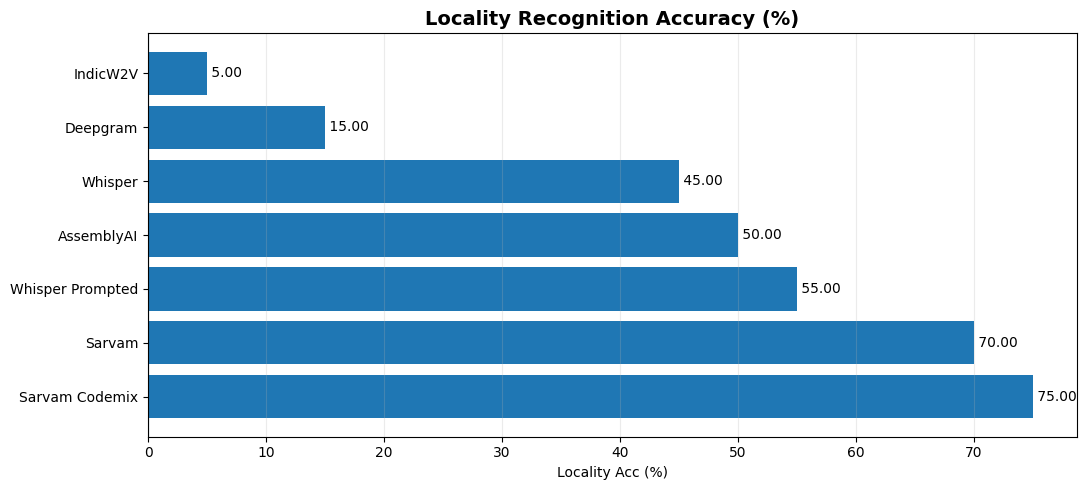

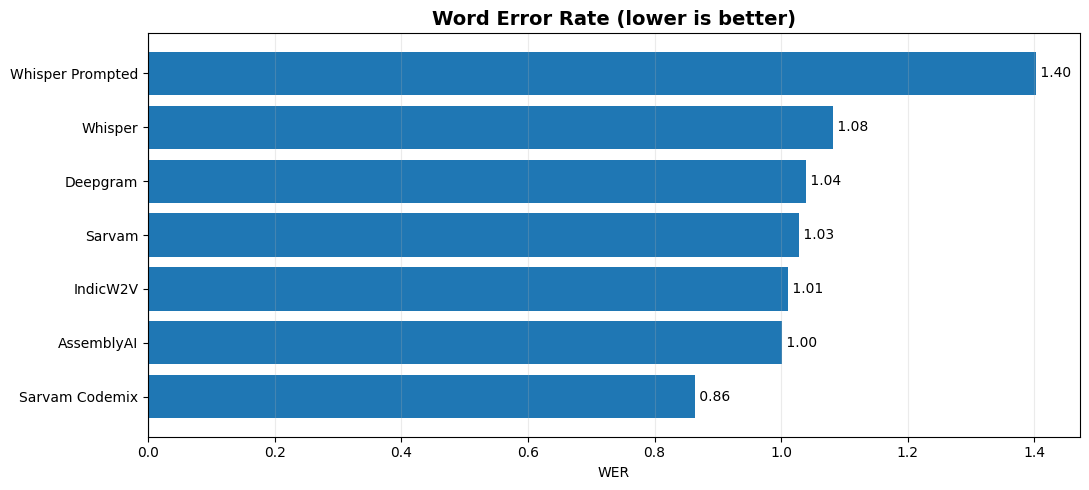

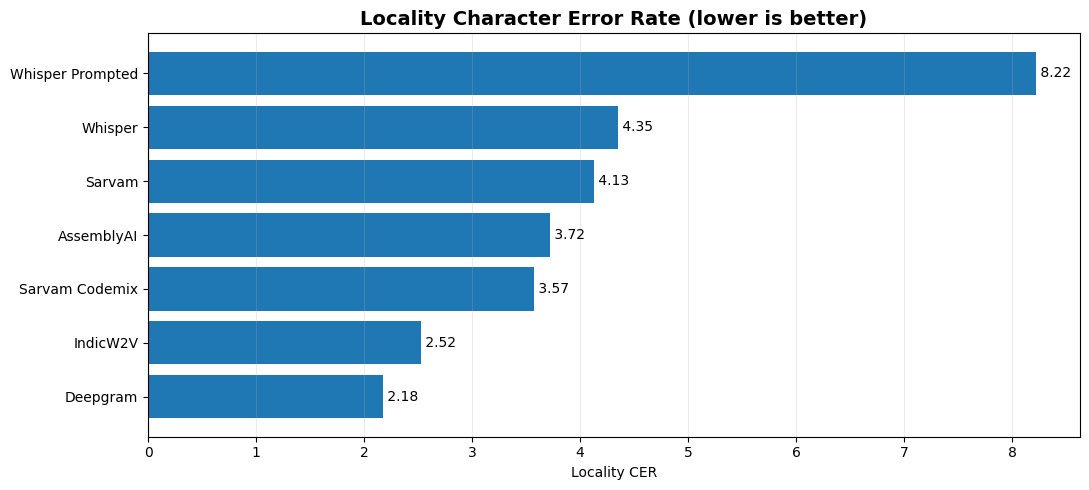

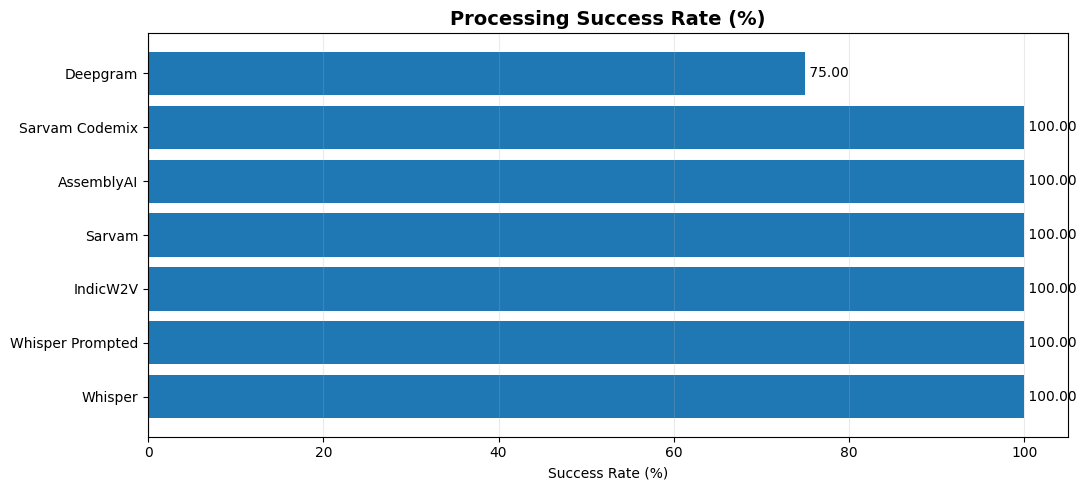

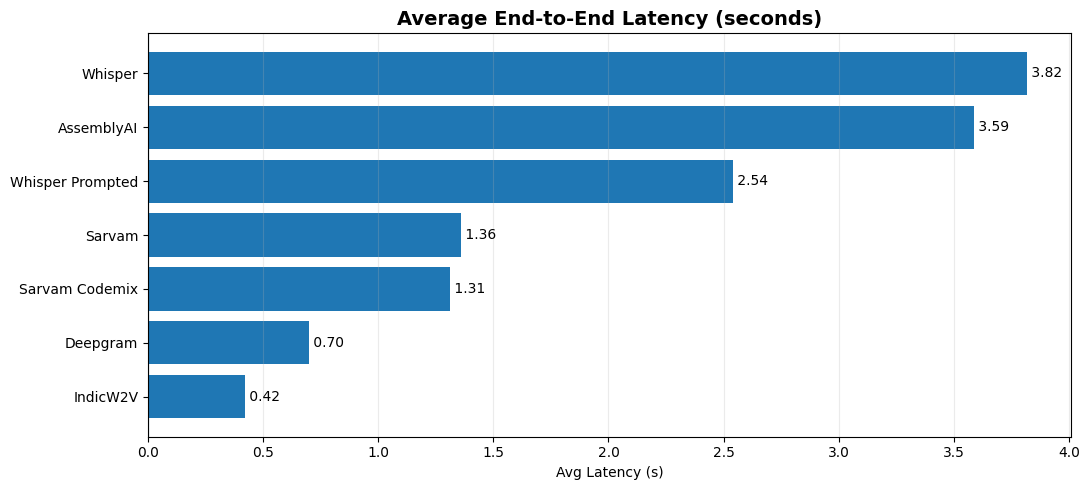

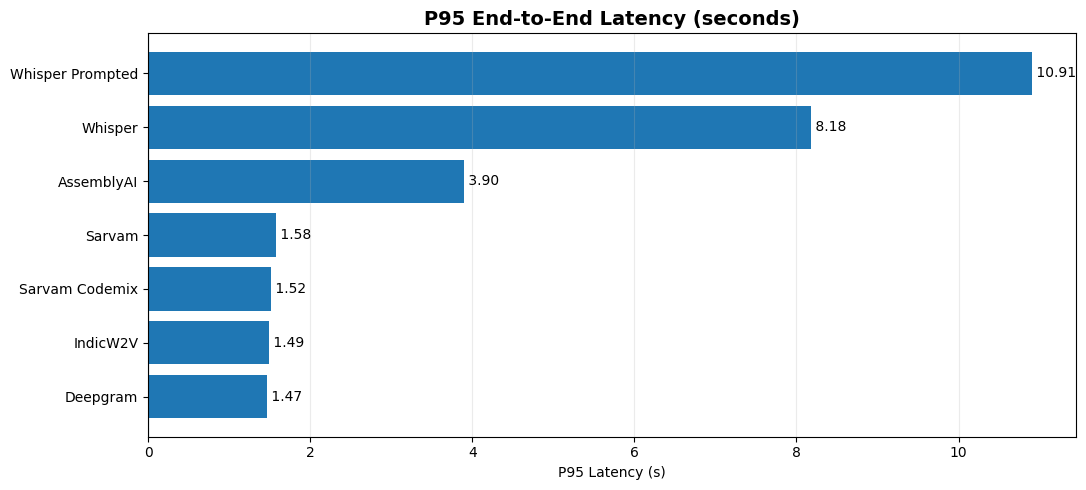

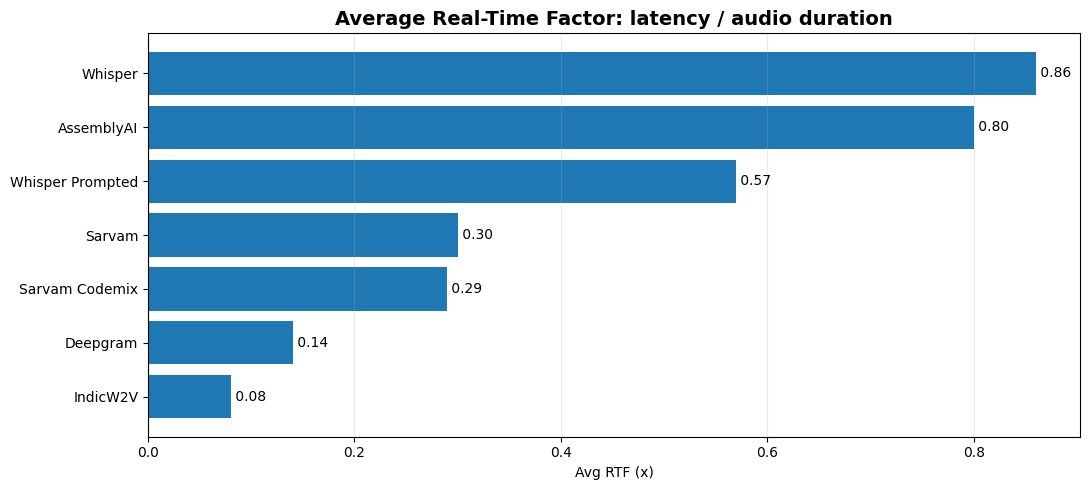

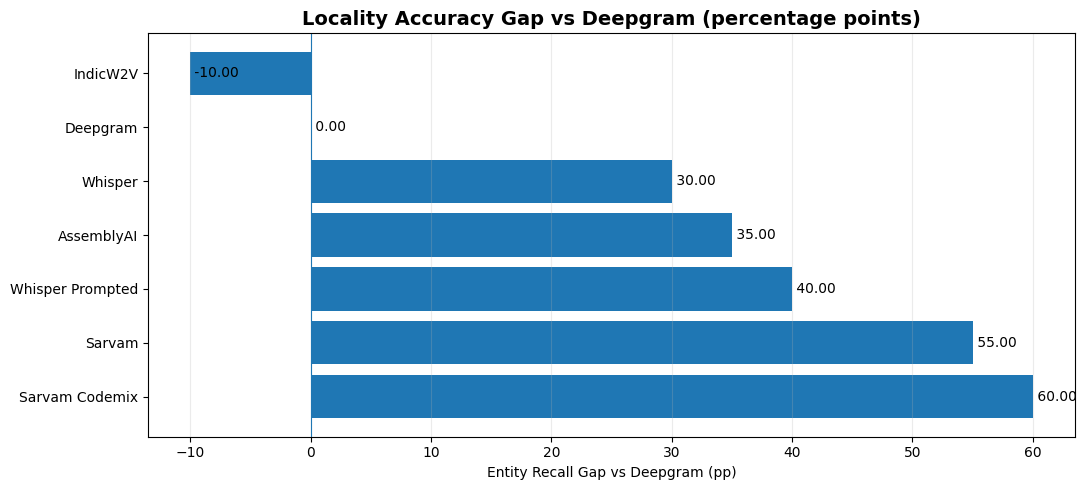

In [ ]:
plot_specs = [
    ('Locality Acc (%)', 'Locality Recognition Accuracy (%)', False),
    ('WER', 'Word Error Rate (lower is better)', True),
    ('Locality CER', 'Locality Character Error Rate (lower is better)', True),
    ('Success Rate (%)', 'Processing Success Rate (%)', False),
    ('Avg Latency (s)', 'Average End-to-End Latency (seconds)', True),
    ('P95 Latency (s)', 'P95 End-to-End Latency (seconds)', True),
    ('Avg RTF (x)', 'Average Real-Time Factor: latency / audio duration', True),
    ('Entity Recall Gap vs Deepgram (pp)', 'Locality Accuracy Gap vs Deepgram (percentage points)', False),
]

for metric, title, lower_is_better in plot_specs:
    fig, ax = plt.subplots(figsize=(11, 5))
    ordered = summary_df.sort_values(metric, ascending=lower_is_better)
    ax.barh(ordered['Model'], ordered[metric])
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel(metric)
    ax.grid(axis='x', alpha=0.25)
    ax.axvline(0, linewidth=0.8)
    for idx, value in enumerate(ordered[metric]):
        label = "NA" if pd.isna(value) else f"{value:.2f}"
        ax.text(value if not pd.isna(value) else 0, idx, f" {label}", va='center')
    plt.tight_layout()
    plt.show()


## 5.3 Normalized Scorecard Heatmap

A compact scorecard helps compare models across heterogeneous metrics. The normalization below converts each metric to a 0-1 score where 1 is best.

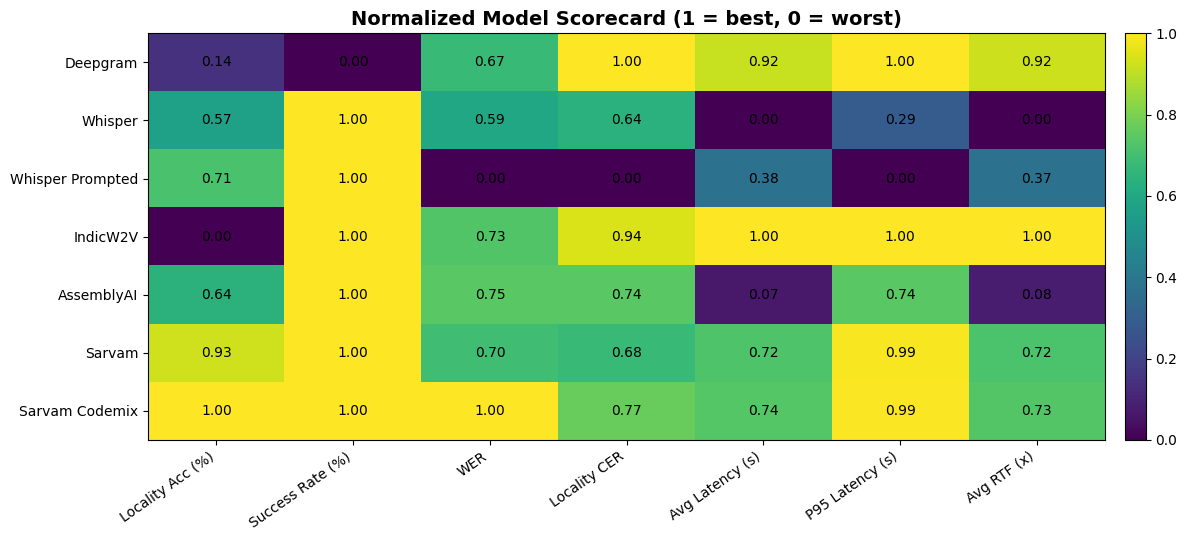

In [ ]:
scorecard = summary_df.set_index('Model')[[
    'Locality Acc (%)', 'WER', 'Locality CER', 'Success Rate (%)', 'Avg Latency (s)', 'P95 Latency (s)', 'Avg RTF (x)'
]].copy()

higher_better = ['Locality Acc (%)', 'Success Rate (%)']
lower_better = ['WER', 'Locality CER', 'Avg Latency (s)', 'P95 Latency (s)', 'Avg RTF (x)']
normalized = pd.DataFrame(index=scorecard.index)

for col in higher_better:
    s = scorecard[col]
    normalized[col] = (s - s.min()) / (s.max() - s.min()) if s.max() != s.min() else 1
for col in lower_better:
    s = scorecard[col]
    normalized[col] = (s.max() - s) / (s.max() - s.min()) if s.max() != s.min() else 1

fig, ax = plt.subplots(figsize=(12, 5.5))
im = ax.imshow(normalized.fillna(0).values, aspect='auto')
ax.set_xticks(np.arange(len(normalized.columns)))
ax.set_yticks(np.arange(len(normalized.index)))
ax.set_xticklabels(normalized.columns, rotation=35, ha='right')
ax.set_yticklabels(normalized.index)
ax.set_title('Normalized Model Scorecard (1 = best, 0 = worst)', fontsize=14, fontweight='bold')

for i in range(normalized.shape[0]):
    for j in range(normalized.shape[1]):
        val = normalized.iloc[i, j]
        ax.text(j, i, 'NA' if pd.isna(val) else f'{val:.2f}', ha='center', va='center')

fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
plt.tight_layout()
plt.show()


## 5.4 Entity Recall vs Transcript Quality Trade-off

This is the most important diagnostic plot for the assignment: WER and locality capture are not the same thing. A model can have relatively high WER but still capture the locality, or lower WER while missing the locality. The top-left quadrant is ideal: low WER and high locality accuracy.

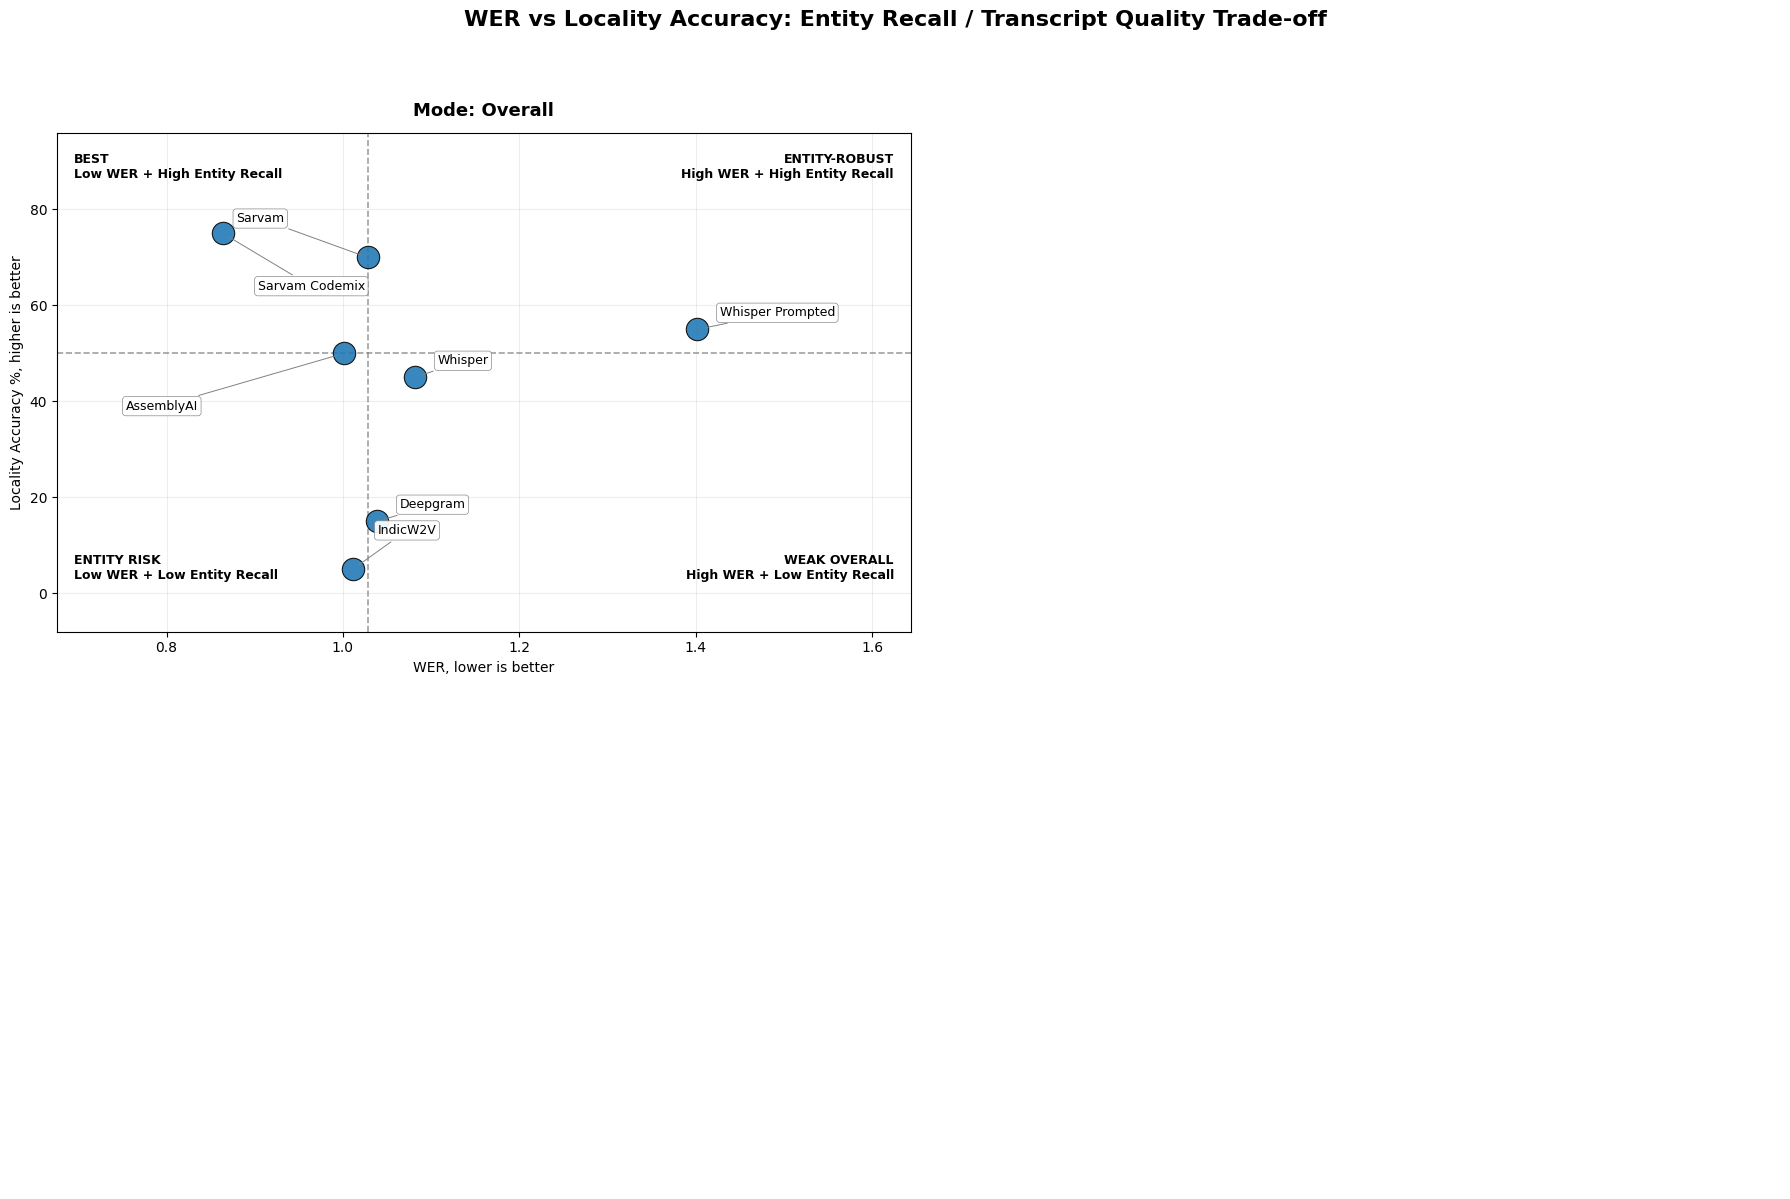

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

mode_col = "Mode"

plot_df = summary_df.copy()

if mode_col not in plot_df.columns:
    plot_df[mode_col] = "Overall"

plot_df["WER"] = pd.to_numeric(plot_df["WER"], errors="coerce")
plot_df["Locality Acc (%)"] = pd.to_numeric(plot_df["Locality Acc (%)"], errors="coerce")
plot_df = plot_df.dropna(subset=["Model", "WER", "Locality Acc (%)", mode_col])

tradeoff_df = (
    plot_df
    .groupby([mode_col, "Model"], as_index=False)
    .agg(
        WER=("WER", "mean"),
        locality_acc=("Locality Acc (%)", "mean")
    )
)

modes = tradeoff_df[mode_col].dropna().unique()[:4]

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

manual_offsets = {
    "Sarvam": (-60, 28),
    "IndicW2V": (18, 28),
    "AssemblyAI": (-105, -38),
    "Sarvam Codemix": (25, -38),
    "Deepgram": (16, 12),
    "Whisper": (16, 12),
    "Whisper Prompted": (16, 12),
}

for idx, ax in enumerate(axes):
    if idx >= len(modes):
        ax.axis("off")
        continue

    mode = modes[idx]
    sub = tradeoff_df[tradeoff_df[mode_col] == mode].copy()

    wer_mid = sub["WER"].median()
    loc_mid = sub["locality_acc"].median()

    x_min, x_max = sub["WER"].min(), sub["WER"].max()
    y_min, y_max = sub["locality_acc"].min(), sub["locality_acc"].max()

    x_range = max(x_max - x_min, 0.20)
    y_range = max(y_max - y_min, 25)

    x_left = x_min - x_range * 0.35
    x_right = x_max + x_range * 0.45
    y_bottom = max(-8, y_min - y_range * 0.35)
    y_top = min(100, y_max + y_range * 0.30)

    ax.set_xlim(x_left, x_right)
    ax.set_ylim(y_bottom, y_top)

    ax.scatter(
        sub["WER"],
        sub["locality_acc"],
        s=260,
        alpha=0.88,
        edgecolors="black",
        linewidths=0.8,
        zorder=3
    )

    for i, row in sub.reset_index(drop=True).iterrows():
        model = row["Model"]
        dx, dy = manual_offsets.get(model, (16, 14 + (i % 4) * 12))

        ax.annotate(
            model,
            xy=(row["WER"], row["locality_acc"]),
            xytext=(dx, dy),
            textcoords="offset points",
            fontsize=9,
            fontweight="medium",
            ha="left" if dx >= 0 else "right",
            va="center",
            bbox=dict(
                boxstyle="round,pad=0.25",
                fc="white",
                ec="gray",
                alpha=0.92,
                linewidth=0.5
            ),
            arrowprops=dict(
                arrowstyle="-",
                color="gray",
                lw=0.7,
                shrinkA=2,
                shrinkB=5
            ),
            zorder=5
        )

    ax.axvline(wer_mid, linestyle="--", linewidth=1.2, color="gray", alpha=0.75)
    ax.axhline(loc_mid, linestyle="--", linewidth=1.2, color="gray", alpha=0.75)

    ax.text(
        0.02, 0.96,
        "BEST\nLow WER + High Entity Recall",
        transform=ax.transAxes,
        va="top",
        ha="left",
        fontsize=9,
        fontweight="bold"
    )

    ax.text(
        0.98, 0.96,
        "ENTITY-ROBUST\nHigh WER + High Entity Recall",
        transform=ax.transAxes,
        va="top",
        ha="right",
        fontsize=9,
        fontweight="bold"
    )

    ax.text(
        0.02, 0.10,
        "ENTITY RISK\nLow WER + Low Entity Recall",
        transform=ax.transAxes,
        va="bottom",
        ha="left",
        fontsize=9,
        fontweight="bold"
    )

    ax.text(
        0.98, 0.10,
        "WEAK OVERALL\nHigh WER + Low Entity Recall",
        transform=ax.transAxes,
        va="bottom",
        ha="right",
        fontsize=9,
        fontweight="bold"
    )

    ax.set_title(f"{mode_col}: {mode}", fontsize=13, fontweight="bold", pad=12)
    ax.set_xlabel("WER, lower is better", fontsize=10)
    ax.set_ylabel("Locality Accuracy %, higher is better", fontsize=10)
    ax.grid(alpha=0.22)

fig.suptitle(
    "WER vs Locality Accuracy: Entity Recall / Transcript Quality Trade-off",
    fontsize=16,
    fontweight="bold",
    y=0.995
)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## 5.5 Language-wise and Noise-wise Comparison


LANGUAGE-WISE PERFORMANCE


,Language,Model,Locality Acc (%),WER,Avg Latency (s),Count
0,Hindi,Deepgram,33.3,0.990,0.46,6
1,Hindi,Whisper,16.7,1.126,3.69,6
2,Hindi,Whisper Prompted,33.3,0.970,2.58,6
3,Hindi,IndicW2V,16.7,1.017,0.15,6
4,Hindi,AssemblyAI,83.3,1.021,3.43,6
5,Hindi,Sarvam,66.7,1.057,1.37,6
6,Hindi,Sarvam Codemix,83.3,0.843,1.27,6
7,Hinglish,Deepgram,50.0,0.778,1.51,2
8,Hinglish,Whisper,0.0,0.944,2.44,2
9,Hinglish,Whisper Prompted,100.0,0.889,1.40,2


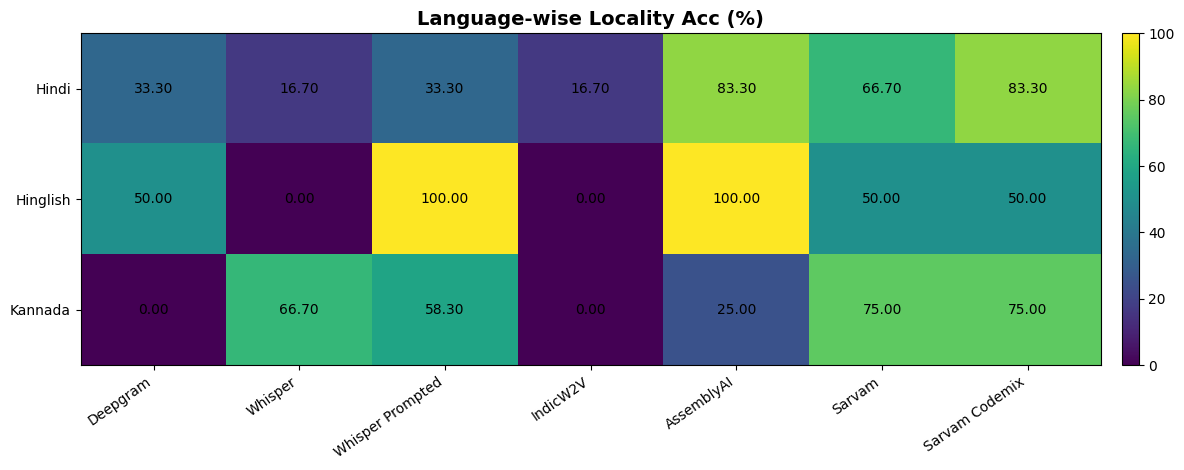

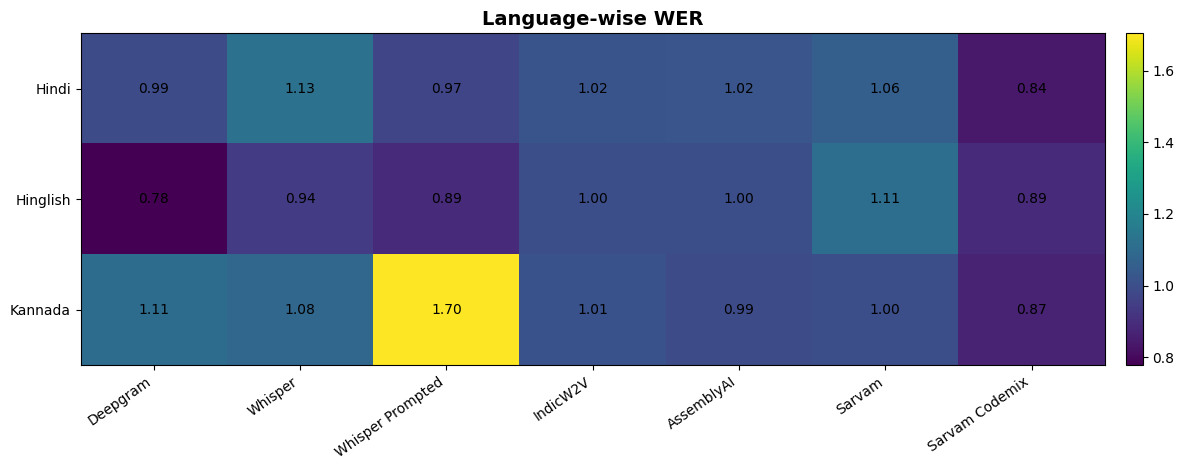


NOISE TYPE IMPACT - LOCALITY ACCURACY (%)


,Deepgram,Whisper,Whisper Prompted,IndicW2V,AssemblyAI,Sarvam,Sarvam Codemix
Noise Type,,,,,,,
Air,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Construction,0.0,100.0,100.0,0.0,100.0,0.0,100.0
Dog,0.0,0.0,0.0,0.0,100.0,100.0,100.0
Fan,0.0,100.0,100.0,0.0,0.0,100.0,100.0
Gaming,0.0,0.0,100.0,0.0,0.0,0.0,0.0
Muffered,0.0,50.0,50.0,0.0,0.0,100.0,100.0
Music,100.0,0.0,100.0,0.0,100.0,100.0,100.0
NoNoise,100.0,0.0,100.0,0.0,100.0,100.0,100.0
People,0.0,50.0,50.0,0.0,50.0,50.0,50.0


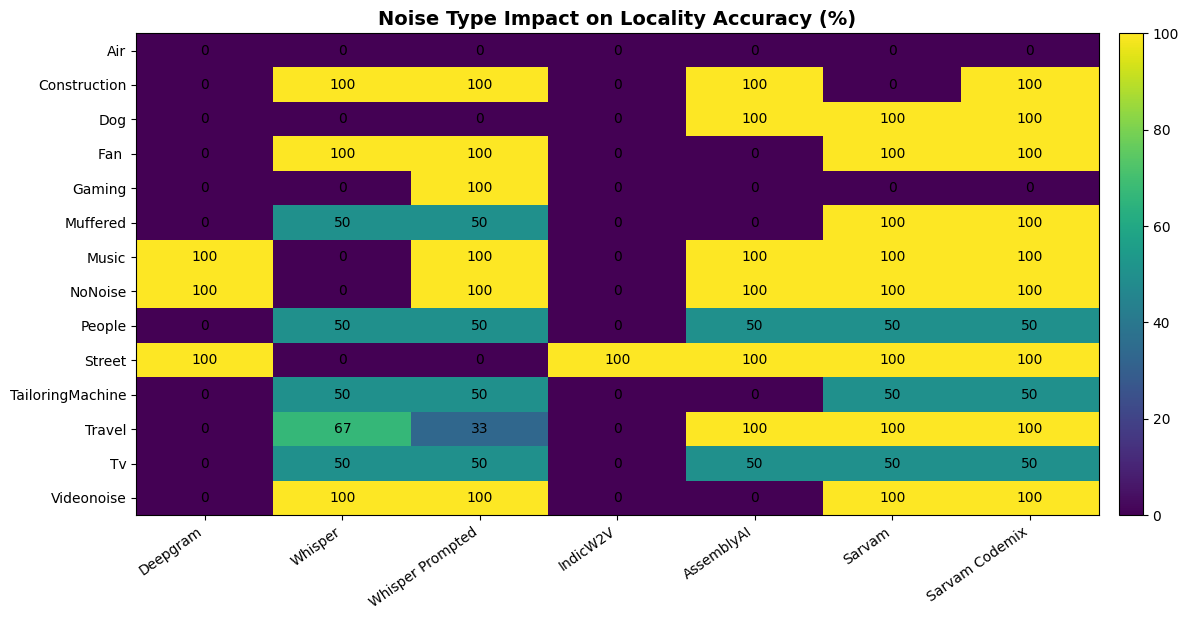

In [ ]:
print("\n" + "="*80)
print("LANGUAGE-WISE PERFORMANCE")
print("="*80)

language_rows = []
for lang, lang_df in final_df.groupby('Language'):
    for model in models:
        language_rows.append({
            'Language': lang,
            'Model': model,
            'Locality Acc (%)': lang_df[f'{model} Locality'].mean() * 100,
            'WER': lang_df[f'{model} WER'].mean(),
            'Avg Latency (s)': pd.to_numeric(lang_df[f'{model} Latency Sec'], errors='coerce').mean(),
            'Count': len(lang_df),
        })
language_perf = pd.DataFrame(language_rows).round({'Locality Acc (%)': 1, 'WER': 3, 'Avg Latency (s)': 2})
display(language_perf)

for metric in ['Locality Acc (%)', 'WER']:
    pivot = language_perf.pivot(index='Language', columns='Model', values=metric)[models]
    fig, ax = plt.subplots(figsize=(12, 4.8))
    im = ax.imshow(pivot.values, aspect='auto')
    ax.set_xticks(np.arange(len(pivot.columns)))
    ax.set_yticks(np.arange(len(pivot.index)))
    ax.set_xticklabels(pivot.columns, rotation=35, ha='right')
    ax.set_yticklabels(pivot.index)
    ax.set_title(f'Language-wise {metric}', fontsize=14, fontweight='bold')
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            ax.text(j, i, f'{pivot.iloc[i, j]:.2f}', ha='center', va='center')
    fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
    plt.tight_layout()
    plt.show()

print("\n" + "="*80)
print("NOISE TYPE IMPACT - LOCALITY ACCURACY (%)")
print("="*80)
noise_analysis = final_df.groupby('Noise Type')[[f'{m} Locality' for m in models]].mean() * 100
noise_analysis.columns = models
noise_analysis = noise_analysis.round(1)
display(noise_analysis)

fig, ax = plt.subplots(figsize=(12, max(5, 0.45 * len(noise_analysis))))
im = ax.imshow(noise_analysis.values, aspect='auto')
ax.set_xticks(np.arange(len(noise_analysis.columns)))
ax.set_yticks(np.arange(len(noise_analysis.index)))
ax.set_xticklabels(noise_analysis.columns, rotation=35, ha='right')
ax.set_yticklabels(noise_analysis.index)
ax.set_title('Noise Type Impact on Locality Accuracy (%)', fontsize=14, fontweight='bold')
for i in range(noise_analysis.shape[0]):
    for j in range(noise_analysis.shape[1]):
        ax.text(j, i, f'{noise_analysis.iloc[i, j]:.0f}', ha='center', va='center')
fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
plt.tight_layout()
plt.show()


## 5.7 Failure Analysis: Locality Misses and Surprising Wins

In [ ]:
failure_rows = []
for _, r in final_df.iterrows():
    for model in models:
        transcript_col = f'{model} Transcript'
        if model == 'Whisper Prompted':
            transcript_col = 'Whisper Prompted Transcript'
        elif model == 'Sarvam Codemix':
            transcript_col = 'Sarvam Codemix Transcript'
        if transcript_col not in final_df.columns:
            continue
        failure_rows.append({
            'Audio File': r['Audio File'],
            'Gender': r.get('Male / Female', ''),
            'Language': r['Language'],
            'Noise Type': r['Noise Type'],
            'Locality': r['Locality'],
            'Model': model,
            'WER': r[f'{model} WER'],
            'Locality Correct': bool(r[f'{model} Locality']),
            'Transcript': r[transcript_col],
        })

failure_df = pd.DataFrame(failure_rows)
misses = failure_df[~failure_df['Locality Correct']].sort_values(['Language', 'Noise Type', 'Model'])
wins_with_high_wer = failure_df[(failure_df['Locality Correct']) & (failure_df['WER'] > failure_df['WER'].median())].sort_values('WER', ascending=False)

print('Locality misses: cases where entity extraction would likely fail downstream')
display(misses[['Audio File', 'Gender', 'Language', 'Noise Type', 'Locality', 'Model', 'WER', 'Transcript']].head(30))

print('Surprising wins: locality captured despite worse full-transcript WER')
display(wins_with_high_wer[['Audio File', 'Gender', 'Language', 'Noise Type', 'Locality', 'Model', 'WER', 'Transcript']].head(20))


Locality misses: cases where entity extraction would likely fail downstream


,Audio File,Gender,Language,Noise Type,Locality,Model,WER,Transcript
126,WhiteField_Male_35_Construction_Hindi.ogg,Male,Hindi,Construction,WhiteField,Deepgram,1.000000,
129,WhiteField_Male_35_Construction_Hindi.ogg,Male,Hindi,Construction,WhiteField,IndicW2V,1.000000,मैं वाइटसिल आईटीपीएल के पास में रहता हूँ
131,WhiteField_Male_35_Construction_Hindi.ogg,Male,Hindi,Construction,WhiteField,Sarvam,1.000000,मैं वाइटफील्ड आईटीपीएल के पास में रहता हूँ।
132,WhiteField_Male_35_Construction_Hindi.ogg,Male,Hindi,Construction,WhiteField,Sarvam Codemix,1.000000,
133,Yeshwanthpur_Male_22_Dog_Hindi.ogg,Male,Hindi,Dog,Yeshwanthpur,Deepgram,1.000000,
136,Yeshwanthpur_Male_22_Dog_Hindi.ogg,Male,Hindi,Dog,Yeshwanthpur,IndicW2V,1.000000,हमा म शंदर मेंट्रोस्टेशन का स्टे करता हूँ
138,Yeshwanthpur_Male_22_Dog_Hindi.ogg,Male,Hindi,Dog,Yeshwanthpur,Sarvam,1.000000,
139,Yeshwanthpur_Male_22_Dog_Hindi.ogg,Male,Hindi,Dog,Yeshwanthpur,Sarvam Codemix,1.000000,
134,Yeshwanthpur_Male_22_Dog_Hindi.ogg,Male,Hindi,Dog,Yeshwanthpur,Whisper,1.181818,कि आप आप आई अश्वंदूर मेट्रो स्टेशन के पास टेक ...
135,Yeshwanthpur_Male_22_Dog_Hindi.ogg,Male,Hindi,Dog,Yeshwanthpur,Whisper Prompted,1.000000,"हां भाई, मैं येश्वन्दूर मेट्रो स्टेशन के पास स..."


Surprising wins: locality captured despite worse full-transcript WER


,Audio File,Gender,Language,Noise Type,Locality,Model,WER,Transcript
2,Banashankari_Female_43_TailoringMachine_Kannad...,Female,Kannada,TailoringMachine,Banashankari,Whisper Prompted,1.125,"Yes sir, I am Banashankari, second stage of th..."
130,WhiteField_Male_35_Construction_Hindi.ogg,Male,Hindi,Construction,WhiteField,AssemblyAI,1.125,मैं वाइट फील आईटीपीएल के पास में रहता हूं।


---
# 6. Export Results

In [ ]:
# Save detailed results, summary, and production slices
os.makedirs(OUTPUT_DIR, exist_ok=True)

output_path = os.path.join(OUTPUT_DIR, "ASR_Benchmark_Final_Results.xlsx")
final_df.to_excel(output_path, index=False)
print(f"\nResults saved to: {output_path}")

summary_path = os.path.join(OUTPUT_DIR, "ASR_Benchmark_Summary_With_Production_Metrics.xlsx")
summary_df.to_excel(summary_path, index=False)
print(f"Summary saved to: {summary_path}")

if 'gender_df' in globals():
    gender_path = os.path.join(OUTPUT_DIR, "ASR_Benchmark_Gender_Comparison.xlsx")
    gender_df.to_excel(gender_path, index=False)
    print(f"Gender comparison saved to: {gender_path}")

if 'language_perf' in globals():
    language_path = os.path.join(OUTPUT_DIR, "ASR_Benchmark_Language_Comparison.xlsx")
    language_perf.to_excel(language_path, index=False)
    print(f"Language comparison saved to: {language_path}")

if 'noise_analysis' in globals():
    noise_path = os.path.join(OUTPUT_DIR, "ASR_Benchmark_Noise_Comparison.xlsx")
    noise_analysis.to_excel(noise_path)
    print(f"Noise comparison saved to: {noise_path}")



Results saved to: /content/drive/MyDrive/ASR_BENCHMARK/output/ASR_Benchmark_Final_Results.xlsx
Summary saved to: /content/drive/MyDrive/ASR_BENCHMARK/output/ASR_Benchmark_Summary_With_Production_Metrics.xlsx
Language comparison saved to: /content/drive/MyDrive/ASR_BENCHMARK/output/ASR_Benchmark_Language_Comparison.xlsx
Noise comparison saved to: /content/drive/MyDrive/ASR_BENCHMARK/output/ASR_Benchmark_Noise_Comparison.xlsx
